# **5. Benchmarks de Segmentación**

En esta fase se implementan y evalúan cinco arquitecturas representativas de segmentación semántica sobre el subconjunto de segmentación de BRISC 2025. El objetivo es establecer líneas base robustas y comparables bajo condiciones experimentales estandarizadas: mismas particiones de datos, mismo preprocesamiento base, misma función de pérdida, mismo optimizador y una política homogénea de entrenamiento.

Las arquitecturas seleccionadas cubren distintas familias de modelos ampliamente utilizadas en segmentación médica:

| Modelo | Familia | Motivación |
|---|---|---|
| U-Net | CNN encoder–decoder | Baseline clásico en segmentación biomédica |
| Attention U-Net | CNN + atención | Refuerza regiones relevantes en skip connections |
| TransUNet | CNN + Transformer | Integra contexto global mediante self-attention |
| UNet++ | CNN con skip connections densas | Mejora la fusión multi-escala |
| DeepLabV3+ | CNN + convoluciones dilatadas | Captura contexto multi-escala con ASPP |

Todos los modelos se entrenan sobre imágenes preprocesadas a $512 \times 512$, en escala de grises, con máscaras binarias, utilizando augmentación moderada exclusivamente en entrenamiento. Dado que el entrenamiento se ejecutará sobre GPU NVIDIA A100 en Colab, la configuración se ajusta para aprovechar mixed precision, paralelismo de carga y una política de entrenamiento más rápida y estable.

---

## 5.1 Configuración del Entorno e Importación de Librerías


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q segmentation-models-pytorch==0.5.0
!pip install -q albumentations==1.4.0
!pip install -q scikit_posthocs

import os
import gc
import re
import time
import copy
import json
import math
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from collections import defaultdict

from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import scikit_posthocs as sp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 70)
print("CONFIGURACIÓN DEL ENTORNO — BENCHMARKS")
print("=" * 70)
print(f"PyTorch:     {torch.__version__}")
print(f"SMP:         {smp.__version__}")
print(f"Device:      {device}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    print(f"VRAM total:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Seed:        {SEED}")
print("=" * 70)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 5.9 MB/s eta 0:00:00
CONFIGURACIÓN DEL ENTORNO — BENCHMARKS
PyTorch:     2.10.0+cu128
SMP:         0.5.0
Device:      cuda
GPU:         NVIDIA A100-SXM4-40GB
VRAM total:  39.5 GB
Seed:        42


## 5.2 Configuración del Entorno y Pipeline de Datos

Para garantizar un flujo de trabajo eficiente y reproducible, iniciamos configurando la estructura de directorios y la gestión de datos en el entorno local. Dado que el dataset BRISC se encuentra comprimido en Google Drive, el proceso comienza con una descompresión optimizada hacia el almacenamiento temporal de la sesión, lo que reduce la latencia durante el entrenamiento.

Un componente central de esta sección es la implementación de la clase `BRISCSegDataset`. Esta clase no solo gestiona la carga de imágenes y máscaras en escala de grises, sino que también preserva metadatos fundamentales como el plano anatómico y el tipo de tumor. Para robustecer el aprendizaje de los modelos de benchmark, hemos diseñado una estrategia de aumento de datos (*data augmentation*) moderada que incluye transformaciones espaciales y ajustes de contraste, cuidando siempre de no distorsionar las características patológicas esenciales. Finalmente, los `DataLoaders` se configuran con trabajadores persistentes y precarga (*prefetching*) para maximizar el uso de la GPU.


In [ ]:
DRIVE_ROOT   = "/content/drive/MyDrive/PRO_TUMORES"
SPLITS_DIR   = os.path.join(DRIVE_ROOT, "splits")
CKPT_DIR     = os.path.join(DRIVE_ROOT, "checkpoints_benchmark")
RESULTS_DIR  = os.path.join(DRIVE_ROOT, "results_benchmark")
FIGURES_DIR  = os.path.join(DRIVE_ROOT, "figures_benchmark")
COLAB_DATA   = "/content/brisc2025"
ZIP_PATH     = os.path.join(DRIVE_ROOT, "brisc2025.zip")

for d in [CKPT_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(COLAB_DATA):
    print("Descomprimiendo dataset...")
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    print(f"Completado en {(time.time()-t0)/60:.2f} min")
else:
    print(f"Dataset disponible en {COLAB_DATA}")

IMG_SIZE    = 512
BATCH_SIZE = 64
NUM_WORKERS = 8 if torch.cuda.is_available() else 4
PIN_MEMORY  = torch.cuda.is_available()

PLANE_TO_IDX = {'Axial': 0, 'Coronal': 1, 'Sagittal': 2}

df_train = pd.read_csv(os.path.join(SPLITS_DIR, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(SPLITS_DIR, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(SPLITS_DIR, 'split_test.csv'))

print("\nSplits cargados:")
print(f"  Train: {len(df_train)}")
print(f"  Val:   {len(df_val)}")
print(f"  Test:  {len(df_test)}")

class BRISCSegDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(
            Image.open(row['image_path']).convert('L'),
            dtype=np.float32
        ) / 255.0

        mask = np.array(
            Image.open(row['mask_path']).convert('L'),
            dtype=np.float32
        ) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask  = transformed['mask']
        else:
            image = torch.from_numpy(image).float()
            mask  = torch.from_numpy(mask).float()

        image = image.float().clamp(0.0, 1.0)
        mask  = (mask > 0.5).float()

        if image.ndim == 2:
            image = image.unsqueeze(0)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        meta = {
            'filename': row['filename'],
            'tumor_label': row['tumor_label'],
            'plane_label': row['plane_label'],
            'plane_idx': torch.tensor(
                PLANE_TO_IDX.get(row['plane_label'], 0),
                dtype=torch.long
            ),
        }
        return image, mask, meta

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=0,
        p=0.30
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.25
    ),
    A.GaussNoise(var_limit=(3.0, 12.0), p=0.15),
    ToTensorV2(),
])

val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
    ToTensorV2(),
])

print("\nTransforms definidos:")
print(f"  Train:    Resize({IMG_SIZE}) + augmentación moderada + ToTensor")
print(f"  Val/Test: Resize({IMG_SIZE}) + ToTensor")
print("  Interpolación imagen: BICUBIC (2)")
print("  Política de máscara: re-binarización post-transform")

train_dataset = BRISCSegDataset(df_train, transforms=train_transforms)
val_dataset   = BRISCSegDataset(df_val,   transforms=val_test_transforms)
test_dataset  = BRISCSegDataset(df_test,  transforms=val_test_transforms)

_dl_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

if NUM_WORKERS > 0:
    _dl_kwargs["prefetch_factor"] = 4

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    **_dl_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **_dl_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **_dl_kwargs
)

print("\nDatasets y DataLoaders creados:")
print(f"\n{'Dataset':<15} {'Samples':>8} {'Batches':>8} {'Transforms':>24}")
print("─" * 62)
print(f"{'Train':<15} {len(train_dataset):>8} {len(train_loader):>8} {'Augmentación moderada':>24}")
print(f"{'Validation':<15} {len(val_dataset):>8} {len(val_loader):>8} {'Preproc only':>24}")
print(f"{'Test':<15} {len(test_dataset):>8} {len(test_loader):>8} {'Preproc only':>24}")

print("\nConfiguración de carga:")
print(f"  Num workers:         {NUM_WORKERS}")
print(f"  Pin memory:          {PIN_MEMORY}")
print(f"  Persistent workers:  {_dl_kwargs['persistent_workers']}")
print(f"  Prefetch factor:     {_dl_kwargs.get('prefetch_factor', 'N/A')}")


Descomprimiendo dataset...
Completado en 0.06 min

Splits cargados:
  Train: 3146
  Val:   787
  Test:  860

Transforms definidos:
  Train:    Resize(512) + augmentación moderada + ToTensor
  Val/Test: Resize(512) + ToTensor
  Interpolación imagen: BICUBIC (2)
  Política de máscara: re-binarización post-transform

Datasets y DataLoaders creados:

Dataset          Samples  Batches               Transforms
──────────────────────────────────────────────────────────────
Train               3146       49    Augmentación moderada
Validation           787       13             Preproc only
Test                 860       14             Preproc only

Configuración de carga:
  Num workers:         8
  Pin memory:          True
  Persistent workers:  True
  Prefetch factor:     4


## 5.3 Validación de Tensores y Estructura de Metadatos

Antes de proceder con la fase de entrenamiento, realizamos una auditoría técnica sobre los `DataLoaders`. Esta verificación es crucial para confirmar que las dimensiones de entrada coinciden con las expectativas de arquitecturas totalmente convolucionales y que los procesos de normalización y binarización se han aplicado correctamente.

En este punto, inspeccionamos no solo los tensores de imagen y máscara, sino también la integridad del diccionario de metadatos. La correcta indexación de los planos anatómicos (Axial, Coronal, Sagital) es de especial interés, ya que constituye la base para el análisis desagregado que diferencia este estudio de la literatura previa sobre el dataset BRISC.

In [ ]:
def verify_batch(loader, name):
    images, masks, metas = next(iter(loader))

    print(f"\n{'='*60}")
    print(f"Verificación: {name}")
    print(f"{'='*60}")
    print(f"Images shape:  {images.shape}")
    print(f"Images dtype:  {images.dtype}")
    print(f"Images range:  [{images.min():.4f}, {images.max():.4f}]")
    print(f"Masks shape:   {masks.shape}")
    print(f"Masks dtype:   {masks.dtype}")
    print(f"Masks unique:  {torch.unique(masks).tolist()}")
    print(f"Masks range:   [{masks.min():.4f}, {masks.max():.4f}]")
    print(f"Meta keys:     {list(metas.keys())}")
    print(f"Tumor labels:  {list(metas['tumor_label'][:4])}")
    print(f"Plane labels:  {list(metas['plane_label'][:4])}")
    print(f"Plane idx:     {metas['plane_idx'][:4].tolist()}")

    checks = {
        'Shape (B, 1, H, W)': images.shape[1:] == (1, IMG_SIZE, IMG_SIZE),
        'Float32': images.dtype == torch.float32,
        'Range [0,1]': images.min() >= 0.0 and images.max() <= 1.0,
        'Mask binary': set(torch.unique(masks).tolist()).issubset({0.0, 1.0}),
        'Mask shape match': masks.shape == images.shape,
        'plane_idx en meta': 'plane_idx' in metas,
        'plane_idx dtype long': metas['plane_idx'].dtype == torch.long,
    }

    print("\nValidaciones:")
    all_ok = True
    for check_name, passed in checks.items():
        status = 'Correcto' if passed else 'ERROR'
        print(f"  {status:<10} {check_name}")
        if not passed:
            all_ok = False

    return all_ok

ok_train = verify_batch(train_loader, "Train DataLoader")
ok_val   = verify_batch(val_loader, "Validation DataLoader")
ok_test  = verify_batch(test_loader, "Test DataLoader")

print(f"\n{'='*60}")
if ok_train and ok_val and ok_test:
    print("TODOS LOS DATALOADERS VERIFICADOS CORRECTAMENTE")
else:
    print("SE DETECTARON PROBLEMAS — REVISAR ARRIBA")
print(f"{'='*60}")



Verificación: Train DataLoader
Images shape:  torch.Size([64, 1, 512, 512])
Images dtype:  torch.float32
Images range:  [0.0000, 1.0000]
Masks shape:   torch.Size([64, 1, 512, 512])
Masks dtype:   torch.float32
Masks unique:  [0.0, 1.0]
Masks range:   [0.0000, 1.0000]
Meta keys:     ['filename', 'tumor_label', 'plane_label', 'plane_idx']
Tumor labels:  ['Pituitary', 'Glioma', 'Pituitary', 'Pituitary']
Plane labels:  ['Coronal', 'Axial', 'Sagittal', 'Axial']
Plane idx:     [1, 0, 2, 0]

Validaciones:
  Correcto   Shape (B, 1, H, W)
  Correcto   Float32
  Correcto   Range [0,1]
  Correcto   Mask binary
  Correcto   Mask shape match
  Correcto   plane_idx en meta
  Correcto   plane_idx dtype long

Verificación: Validation DataLoader
Images shape:  torch.Size([64, 1, 512, 512])
Images dtype:  torch.float32
Images range:  [0.0000, 1.0000]
Masks shape:   torch.Size([64, 1, 512, 512])
Masks dtype:   torch.float32
Masks unique:  [0.0, 1.0]
Masks range:   [0.0000, 1.0000]
Meta keys:     ['file


**Interpretación de resultados:**

La auditoría de los cargadores de datos arroja resultados satisfactorios en todos los splits analizados. Entre los puntos más relevantes destacan:


* **Consistencia Dimensional:** Se confirma que tanto las imágenes como las máscaras mantienen un shape de $(64, 1, 512, 512)$. La presencia del canal único indica que la conversión a escala de grises y el manejo de dimensiones extra (*squeezing/unsqueezing*) operan según lo previsto para arquitecturas tipo U-Net.

* **Integridad de Máscaras:** El rango de las máscaras es estrictamente $\{0, 1\}$ con tipo de dato `float32`. Esto garantiza que no existan valores espurios producto de la interpolación durante las transformaciones de aumento de datos, lo cual es vital para el cálculo preciso del *Dice Score*.

* **Rastreabilidad de Metadatos:** La presencia de `plane_idx` con tipo `long` y las etiquetas de tumor asociadas a cada batch permiten validar que el pipeline de datos preserva la identidad clínica de cada muestra. Esto asegura que podamos segmentar el rendimiento por tipo de tumor y plano anatómico en las etapas finales del benchmark sin pérdida de información.



## 5.4 Definición de Funciones de Pérdida y Métricas de Evaluación

En tareas de segmentación de imágenes médicas, la elección de la función de pérdida es determinante para manejar el desbalance entre los píxeles del tumor y el tejido sano. En este flujo, hemos implementado una `ComboLoss` que combina la robustez de la *Binary Cross Entropy* (BCE) con la sensibilidad estructural de la *Dice Loss*. Mientras que BCE penaliza las clasificaciones erróneas a nivel de píxel, Dice Loss optimiza directamente el solapamiento global de las regiones segmentadas.

Complementariamente, definimos el coeficiente Dice y la Intersección sobre la Unión (IoU) como métricas principales de evaluación. Estas se calculan de manera binarizada tras aplicar un umbral sigmoide, permitiendo monitorear la capacidad de generalización de los modelos de benchmark en cada época de entrenamiento.

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)
        intersection = (pred_flat * target_flat).sum()

        dice = (2.0 * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1.0 - dice


class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return (
            self.alpha * self.dice_loss(pred, target)
            + (1 - self.alpha) * self.bce_loss(pred, target)
        )


def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    return (intersection + smooth) / (union + smooth)


def compute_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    return (2.0 * intersection + smooth) / (
        pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth
    )


print("Funciones de pérdida y métricas definidas.")
print("  Loss:    ComboLoss (0.5 · Dice + 0.5 · BCE)")
print("  Metrics: IoU, Dice Score")


Funciones de pérdida y métricas definidas.
  Loss:    ComboLoss (0.5 · Dice + 0.5 · BCE)
  Metrics: IoU, Dice Score



**Interpretación técnica:**

La arquitectura de las funciones definidas presenta varias ventajas estratégicas para el dataset BRISC:

* **Estabilidad Numérica:** El uso de `BCEWithLogitsLoss` y la aplicación interna de `sigmoid` en las funciones de métricas previene problemas de gradientes explosivos o desvanecientes al trabajar con valores de probabilidad crudos (logits).

* **Suavizado de Dice (Smoothing):** La inclusión del parámetro `smooth` en el cálculo de la intersección previene divisiones por cero, especialmente en las etapas iniciales del entrenamiento o en casos donde la región tumoral es extremadamente pequeña.

* **Balanceo Dinámico:** Al establecer un parámetro $\alpha = 0.5$ en la `ComboLoss`, otorgamos igual importancia a la precisión por píxel y a la coherencia de la forma segmentada. Este equilibrio suele ser superior al uso de una única métrica en tumores con bordes difusos o morfologías irregulares.

## 5.5 Diseño del Motor de Entrenamiento y Optimización

Para garantizar una comparación justa entre los distintos modelos de benchmark, hemos desarrollado un motor de entrenamiento robusto y altamente optimizado. Este núcleo integra tres componentes fundamentales: el uso de Precisión Mixta Automática (AMP) para acelerar los cálculos en GPU, un sistema de parada temprana (*Early Stopping*) basado en la paciencia del modelo para prevenir el sobreajuste, y un programador de la tasa de aprendizaje (*Learning Rate Scheduler*) que se ajusta dinámicamente según el rendimiento en el conjunto de validación.

La lógica se encapsula en una función principal que no solo gestiona el bucle de entrenamiento y validación, sino que también automatiza el guardado del mejor estado del modelo y el registro detallado del historial de métricas. Este enfoque modular permite evaluar arquitecturas de diversa complejidad (desde U-Net hasta TransUNet) bajo condiciones experimentales idénticas, asegurando la validez científica de los resultados.

In [ ]:
HPARAMS = {
    'max_epochs': 500,
    'patience': 80,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'scheduler_patience': 20,
    'scheduler_factor': 0.5,
    'min_lr': 1e-7,
    'grad_clip': 1.0,
}




print("Hiperparámetros compartidos:")
for k, v in HPARAMS.items():
    print(f"  {k}: {v}")

AMP_ENABLED = torch.cuda.is_available()
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_one_epoch(model, loader, criterion, optimizer, scaler, device, grad_clip=1.0):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            running_loss += loss.item()
            running_iou += compute_iou(outputs, masks).mean().item()
            running_dice += compute_dice(outputs, masks).mean().item()
            n_batches += 1

    return {
        'loss': running_loss / n_batches,
        'iou': running_iou / n_batches,
        'dice': running_dice / n_batches,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, masks)

        running_loss += loss.item()
        running_iou += compute_iou(outputs, masks).mean().item()
        running_dice += compute_dice(outputs, masks).mean().item()
        n_batches += 1

    return {
        'loss': running_loss / n_batches,
        'iou': running_iou / n_batches,
        'dice': running_dice / n_batches,
    }


def train_model(model, model_name, train_loader, val_loader, device, hparams=HPARAMS):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO: {model_name}")
    print(f"{'='*70}")

    total_p = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales:      {total_p:,}")
    print(f"Parámetros entrenables:  {trainable_p:,}")
    print(f"Tamaño estimado:         {total_p*4/1024**2:.1f} MB")

    model = model.to(device)
    criterion = ComboLoss(alpha=0.5)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=hparams['learning_rate'],
        weight_decay=hparams['weight_decay']
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=hparams['scheduler_factor'],
        patience=hparams['scheduler_patience'],
        min_lr=hparams['min_lr']
    )

    scaler = GradScaler(device='cuda', enabled=AMP_ENABLED)

    history = {
        'train_loss': [],
        'train_iou': [],
        'train_dice': [],
        'val_loss': [],
        'val_iou': [],
        'val_dice': [],
        'lr': [],
    }

    best_val_dice = -1.0
    best_model_state = None
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')

    for epoch in range(1, hparams['max_epochs'] + 1):
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            grad_clip=hparams['grad_clip']
        )
        val_metrics = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_metrics['dice'])

        history['train_loss'].append(train_metrics['loss'])
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['lr'].append(current_lr)

        improved = val_metrics['dice'] > best_val_dice

        if improved:
            best_val_dice = val_metrics['dice']
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
            marker = "BEST"

            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model_state,
                'val_dice': best_val_dice,
                'val_iou': val_metrics['iou'],
                'history_length': len(history['train_loss']),
                'hparams': hparams,
            }, ckpt_path)
        else:
            patience_counter += 1
            marker = f"patience {patience_counter}/{hparams['patience']}"

        print(
            f"Epoch {epoch:03d}/{hparams['max_epochs']} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train IoU: {train_metrics['iou']:.4f} | "
            f"Train Dice: {train_metrics['dice']:.4f} || "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"{time.time()-epoch_start:.1f}s | {marker}"
        )

        if patience_counter >= hparams['patience']:
            print(f"\nEarly Stopping activado en epoch {epoch}.")
            print(f"Mejor epoch: {best_epoch} | Mejor Val Dice: {best_val_dice:.4f}")
            break

    model.load_state_dict(best_model_state)

    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    total_time = time.time() - start_time

    print(f"\nResumen de entrenamiento — {model_name}")
    print("─" * 60)
    print(f"Mejor epoch:     {best_epoch}")
    print(f"Mejor Val Dice:  {best_val_dice:.4f}")
    print(f"Mejor Val IoU:   {history['val_iou'][best_epoch-1]:.4f}")
    print(f"Tiempo total:    {total_time/60:.1f} min")
    print(f"Checkpoint:      {ckpt_path}")
    print(f"Historial:       {history_path}")

    return model, history


print("\nMotor de entrenamiento definido.")


Hiperparámetros compartidos:
  max_epochs: 500
  patience: 80
  learning_rate: 0.0002
  weight_decay: 0.0001
  scheduler_patience: 20
  scheduler_factor: 0.5
  min_lr: 1e-07
  grad_clip: 1.0

Motor de entrenamiento definido.


**Interpretación:**

El diseño del motor revela decisiones de ingeniería orientadas al alto rendimiento en Deep Learning:

* **Gestión de Recursos:** La inclusión de `clear_memory` y el uso de `set_to_none=True` en la limpieza de gradientes son prácticas óptimas para manejar imágenes de alta resolución ($512 \times 512$) sin saturar la memoria VRAM de la GPU.

* **Estabilidad del Aprendizaje:** El uso de `AdamW` junto con el recorte de gradientes (`grad_clip`) protege al modelo contra actualizaciones abruptas que podrían desestabilizar los pesos, un problema común en arquitecturas basadas en *Attention* o *Transformers*.

* **Criterio de Persistencia:** Al guardar el estado del modelo basándonos en el `best_val_dice`, priorizamos la métrica que mejor representa el éxito clínico en la segmentación de tumores, asegurando que el modelo final sea el que mejor generaliza ante datos no vistos.


## 5.6 Evaluación Detallada y Persistencia de Resultados

Para validar la eficacia de los modelos en un entorno clínico simulado, hemos diseñado un protocolo de evaluación que trasciende las métricas globales. La función `evaluate_detailed` permite inspeccionar el rendimiento del sistema no solo mediante el *Weighted mIoU* métrica de referencia en el estudio original de BRISC sino también a través de una matriz de desempeño cruzado entre tipos de tumor y planos anatómicos (Axial, Coronal y Sagital).

Este nivel de granularidad es esencial para identificar si una arquitectura presenta sesgos de aprendizaje hacia una orientación específica o si su capacidad de segmentación varía según la morfología característica de cada patología (Glioma, Meningioma o Pituitaria). Adicionalmente, se implementa un sistema de persistencia en Drive que gestiona los puntos de control (*checkpoints*) y registros históricos, permitiendo la reproducibilidad de los experimentos y la recuperación de sesiones de entrenamiento interrumpidas.

In [ ]:
@torch.no_grad()
def evaluate_detailed(model, loader, device, model_name="Model"):
    model.eval()
    all_results = []

    for images, masks, metas in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)

        ious = compute_iou(outputs, masks)
        dices = compute_dice(outputs, masks)

        for i in range(len(images)):
            all_results.append({
                'filename': metas['filename'][i],
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'iou': ious[i].item(),
                'dice': dices[i].item(),
            })

    results_df = pd.DataFrame(all_results)

    tumor_iou = results_df.groupby('tumor_label')['iou'].mean()
    tumor_counts = results_df.groupby('tumor_label')['iou'].count()
    total_samples = tumor_counts.sum()
    weighted_miou = (tumor_iou * tumor_counts / total_samples).sum()

    plane_iou = results_df.groupby('plane_label')['iou'].mean()
    cross_iou = results_df.groupby(['tumor_label', 'plane_label'])['iou'].mean()

    global_iou = results_df['iou'].mean()
    global_dice = results_df['dice'].mean()

    summary = {
        'model_name': model_name,
        'global_iou': global_iou,
        'global_dice': global_dice,
        'weighted_miou': weighted_miou,
        'tumor_iou': tumor_iou.to_dict(),
        'plane_iou': plane_iou.to_dict(),
        'cross_iou': cross_iou.to_dict(),
        'tumor_dice': results_df.groupby('tumor_label')['dice'].mean().to_dict(),
        'plane_dice': results_df.groupby('plane_label')['dice'].mean().to_dict(),
    }

    print(f"\n{'='*70}")
    print(f"RESULTADOS EN TEST — {model_name}")
    print(f"{'='*70}")
    print(f"Weighted mIoU:  {weighted_miou*100:.2f}%")
    print(f"Global mIoU:    {global_iou*100:.2f}%")
    print(f"Global Dice:    {global_dice*100:.2f}%")

    print("\nmIoU por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        print(f"  {t:<15} {tumor_iou.get(t, 0)*100:.2f}%")

    print("\nmIoU por Plano Anatómico:")
    for p in ['Axial', 'Coronal', 'Sagittal']:
        print(f"  {p:<15} {plane_iou.get(p, 0)*100:.2f}%")

    print("\nmIoU por Tumor × Plano:")
    cross_table = results_df.pivot_table(
        values='iou',
        index='tumor_label',
        columns='plane_label',
        aggfunc='mean'
    ).reindex(
        index=['Glioma', 'Meningioma', 'Pituitary'],
        columns=['Axial', 'Coronal', 'Sagittal']
    ) * 100
    print(cross_table.round(2).to_string())

    return results_df, summary


def save_model_results(model_name, model, history, test_loader, device):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    results_df, summary = evaluate_detailed(
        model=model,
        loader=test_loader,
        device=device,
        model_name=model_name
    )

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv'),
        index=False
    )

    summary_serializable = {}
    for k, v in summary.items():
        if isinstance(v, dict):
            summary_serializable[k] = {str(kk): vv for kk, vv in v.items()}
        else:
            summary_serializable[k] = v

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'w') as f:
        json.dump(summary_serializable, f, indent=2)

    print(f"\nResultados de {model_name} guardados en Drive")
    print(f"  • {safe_name}_test_results.csv ({len(results_df)} imágenes)")
    print(f"  • {safe_name}_summary.json")

    return results_df, summary


def model_already_trained(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    summary_path = os.path.join(RESULTS_DIR, f'{safe_name}_summary.json')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')

    exists = all(os.path.exists(p) for p in [ckpt_path, summary_path, history_path])

    if exists:
        ck = torch.load(ckpt_path, map_location='cpu')
        print(f"  {model_name} encontrado — Val Dice: {ck['val_dice']:.4f} (epoch {ck['epoch']})")

    return exists


def load_model_from_checkpoint(build_fn, model_name, device):
    model = build_fn()
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck['model_state_dict'])
    model = model.to(device).eval()
    print(f"  {model_name} cargado desde checkpoint (Val Dice: {ck['val_dice']:.4f})")
    return model


def load_saved_results(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_history.json'), 'r') as f:
        history = json.load(f)

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'r') as f:
        summary = json.load(f)

    results_df = pd.read_csv(
        os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv')
    )

    print(f"  Resultados cargados: {len(results_df)} imágenes, {len(history['train_loss'])} epochs")
    return history, summary, results_df


print("Funciones auxiliares de evaluación definidas.")


Funciones auxiliares de evaluación definidas.


## 5.7 Funciones de Visualización

In [ ]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    for ax, tr, vl, lbl in zip(
        axes,
        ['train_loss', 'train_iou', 'train_dice'],
        ['val_loss',   'val_iou',   'val_dice'],
        ['Loss', 'IoU', 'Dice Score']
    ):
        ax.plot(epochs, history[tr], label='Train', linewidth=1.8)
        ax.plot(epochs, history[vl], label='Validation', linewidth=1.8)
        ax.set_title(f'{model_name} — {lbl}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(lbl)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Curvas de Entrenamiento — {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_curves.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


@torch.no_grad()
def visualize_predictions(model, loader, device, model_name, n_samples=6):
    model.eval()
    images_list, masks_list, preds_list, metas_list = [], [], [], []

    for images, masks, metas in loader:
        images_gpu = images.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images_gpu)

        preds = (torch.sigmoid(outputs) > 0.5).float().cpu()

        for i in range(len(images)):
            images_list.append(images[i])
            masks_list.append(masks[i])
            preds_list.append(preds[i])
            metas_list.append({
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'filename': metas['filename'][i],
            })

        if len(images_list) >= n_samples:
            break

    n_samples = min(n_samples, len(images_list))
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 3.5))

    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_samples):
        img_np = np.clip(images_list[i][0].numpy(), 0, 1)
        gt_np = masks_list[i][0].numpy()
        pred_np = preds_list[i][0].numpy()
        meta = metas_list[i]

        overlay = np.stack([img_np, img_np, img_np], axis=-1)
        tp = (gt_np == 1) & (pred_np == 1)
        fn = (gt_np == 1) & (pred_np == 0)
        fp = (gt_np == 0) & (pred_np == 1)
        overlay[tp] = [0.0, 0.8, 0.0]
        overlay[fn] = [0.9, 0.0, 0.0]
        overlay[fp] = [0.0, 0.3, 0.9]

        intersection = tp.sum()
        union = (gt_np == 1).sum() + (pred_np == 1).sum() - intersection
        iou = intersection / (union + 1e-6)

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title(f"{meta['tumor_label']}/{meta['plane_label']}", fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_np, cmap='gray')
        axes[i, 1].set_title('Ground Truth', fontsize=9)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='gray')
        axes[i, 2].set_title('Predicción', fontsize=9)
        axes[i, 2].axis('off')

        axes[i, 3].imshow(np.clip(overlay, 0, 1))
        axes[i, 3].set_title(f'Overlay — IoU: {iou*100:.1f}%', fontsize=9)
        axes[i, 3].axis('off')

    for ax, t in zip(
        axes[0],
        ['Imagen MRI', 'Ground Truth', 'Predicción', 'Overlay (🟢TP 🔴FN 🔵FP)']
    ):
        ax.set_title(t, fontsize=10, fontweight='bold')

    fig.suptitle(f'Predicciones en Test — {model_name}', fontsize=14, y=1.01)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_predictions.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


@torch.no_grad()
def visualize_best_worst(model, results_df, df_test_ref, device, model_name, n=5):
    model.eval()

    results_with_paths = results_df.merge(
        df_test_ref[['filename', 'image_path', 'mask_path']],
        on='filename',
        how='left'
    )

    best = results_with_paths.nlargest(n, 'iou')
    worst = results_with_paths.nsmallest(n, 'iou')

    fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))

    for row_idx, (subset, label) in enumerate([(best, 'Mejores'), (worst, 'Peores')]):
        for col_idx, (_, sample) in enumerate(subset.iterrows()):
            img = np.array(Image.open(sample['image_path']).convert('L'), dtype=np.float32) / 255.0
            mask = np.array(Image.open(sample['mask_path']).convert('L'), dtype=np.float32) / 255.0
            mask = (mask > 0.5).astype(np.float32)

            transform = A.Compose([
                A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
                ToTensorV2()
            ])
            result = transform(image=img, mask=mask)

            img_t = result['image'].clamp(0, 1).unsqueeze(0).to(device)

            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(model(img_t)) > 0.5).float().cpu().squeeze().numpy()

            img_np = np.clip(result['image'].squeeze().numpy(), 0, 1)
            gt_np = result['mask'].numpy()

            overlay = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np == 1) & (pred == 1)
            fn = (gt_np == 1) & (pred == 0)
            fp = (gt_np == 0) & (pred == 1)

            overlay[tp] = [0.0, 0.8, 0.0]
            overlay[fn] = [0.9, 0.0, 0.0]
            overlay[fp] = [0.0, 0.3, 0.9]

            axes[row_idx, col_idx].imshow(np.clip(overlay, 0, 1))
            axes[row_idx, col_idx].set_title(
                f"{sample['tumor_label'][:3]}/{sample['plane_label'][:3]}\nIoU: {sample['iou']*100:.1f}%",
                fontsize=9
            )
            axes[row_idx, col_idx].axis('off')

    axes[0, 0].set_ylabel('Mejores', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Peores', fontsize=12, fontweight='bold')
    fig.suptitle(f'Top {n} Mejores y Peores — {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_best_worst.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


print("Funciones de visualización definidas.")


Funciones de visualización definidas.


In [ ]:
def print_model_metrics(model_name, summary):
    sc = 100 if summary['weighted_miou'] < 1 else 1

    print(f"\n{'='*70}")
    print(f"MÉTRICAS EN TEST — {model_name}")
    print(f"{'='*70}")
    print(f"Weighted mIoU:  {summary['weighted_miou']*sc:.2f}%")
    print(f"Global mIoU:    {summary['global_iou']*sc:.2f}%")
    print(f"Global Dice:    {summary['global_dice']*sc:.2f}%")

    print("\nmIoU por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        val = summary['tumor_iou'].get(t, 0)
        print(f"  {t:<15} {val*sc:.2f}%")

    print("\nDice por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        val = summary['tumor_dice'].get(t, 0)
        print(f"  {t:<15} {val*sc:.2f}%")

    print("\nmIoU por Plano Anatómico:")
    for p in ['Axial', 'Coronal', 'Sagittal']:
        val = summary['plane_iou'].get(p, 0)
        print(f"  {p:<15} {val*sc:.2f}%")

## 5.8 Definición de Arquitecturas

### 5.8.1 U-Net

In [ ]:
def build_unet():
    return smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("U-Net definido (encoder: ResNet34, pretrained: ImageNet)")


U-Net definido (encoder: ResNet34, pretrained: ImageNet)


### 5.8.2 Attention U-Net

In [ ]:
def build_attention_unet():
    return smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None,
        decoder_attention_type='scse'
    )

print("Attention U-Net definido (encoder: ResNet34, attention: scSE)")


Attention U-Net definido (encoder: ResNet34, attention: scSE)


### 5.8.3 TransUNet

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=drop,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        xn = self.norm1(x)
        a, _ = self.attn(xn, xn, xn)
        x = x + a
        x = x + self.ffn(self.norm2(x))
        return x


class TransUNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        num_classes=1,
        img_size=512,
        transformer_dim=256,
        num_heads=8,
        num_layers=4,
        drop=0.1
    ):
        super().__init__()
        self.img_size = img_size

        import torchvision.models as models
        resnet = models.resnet34(weights='IMAGENET1K_V1')

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight.copy_(resnet.conv1.weight.mean(dim=1, keepdim=True))

        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3

        self.proj = nn.Conv2d(256, transformer_dim, kernel_size=1)

        self.transformer = nn.Sequential(*[
            TransformerBlock(
                dim=transformer_dim,
                num_heads=num_heads,
                mlp_ratio=4.0,
                drop=drop
            )
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(transformer_dim)

        self.up3 = nn.ConvTranspose2d(transformer_dim, 128, kernel_size=2, stride=2)
        self.dec3 = self._double_conv(128 + 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self._double_conv(64 + 64, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = self._double_conv(32 + 64, 32)

        self.up0 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def _double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)

        t = self.proj(s3)
        B, C, H, W = t.shape
        t = t.flatten(2).permute(0, 2, 1)
        t = self.transformer(t)
        t = self.norm(t)
        t = t.permute(0, 2, 1).reshape(B, C, H, W)

        d3 = self.up3(t)
        d3 = self.dec3(torch.cat([d3, s2], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, s1], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, x0], dim=1))

        d0 = self.up0(d1)
        return self.final(d0)


def build_transunet():
    return TransUNet(
        in_channels=1,
        num_classes=1,
        img_size=IMG_SIZE,
        transformer_dim=256,
        num_heads=8,
        num_layers=4,
        drop=0.1
    )

print("TransUNet definido (encoder: ResNet34 + 4 Transformer blocks)")


TransUNet definido (encoder: ResNet34 + 4 Transformer blocks)


### 5.8.4 UNet++

In [ ]:
def build_unetplusplus():
    return smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("UNet++ definido (encoder: ResNet34, pretrained: ImageNet)")


UNet++ definido (encoder: ResNet34, pretrained: ImageNet)


### 5.8.5 DeepLabV3+

In [ ]:
def build_deeplabv3plus():
    return smp.DeepLabV3Plus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("DeepLabV3+ definido (encoder: ResNet34, pretrained: ImageNet)")


DeepLabV3+ definido (encoder: ResNet34, pretrained: ImageNet)


## 5.9 Inicialización del Benchmark

In [ ]:
BENCHMARK_MODELS = [
    ('UNet', build_unet),
    ('AttentionUNet', build_attention_unet),
    ('TransUNet', build_transunet),
    ('UNetPlusPlus', build_unetplusplus),
    ('DeepLabV3Plus', build_deeplabv3plus),
]

all_summaries = {}
all_results = {}
all_histories = {}

print("Benchmark inicializado.")
print(f"Modelos: {[n for n, _ in BENCHMARK_MODELS]}")

print("\nVerificando modelos ya entrenados...\n")
for model_name, _ in BENCHMARK_MODELS:
    model_already_trained(model_name)


Benchmark inicializado.
Modelos: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Verificando modelos ya entrenados...

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)


## 5.10 Entrenamiento Secuencial de los Benchmarks

En esta subsección se define la lista oficial de arquitecturas del benchmark y se inicializan los contenedores donde se almacenarán historiales, resultados y resúmenes. Esta celda no entrena modelos; únicamente prepara el entorno para ejecutar cada arquitectura de forma independiente en celdas separadas.

In [ ]:
BENCHMARK_MODELS = [
    ('UNet', build_unet),
    ('AttentionUNet', build_attention_unet),
    ('TransUNet', build_transunet),
    ('UNetPlusPlus', build_unetplusplus),
    ('DeepLabV3Plus', build_deeplabv3plus),
]

all_summaries = {}
all_results   = {}
all_histories = {}

print("Benchmark inicializado.")
print(f"Modelos: {[n for n, _ in BENCHMARK_MODELS]}")

print("\nVerificando modelos ya entrenados...\n")
for model_name, _ in BENCHMARK_MODELS:
    model_already_trained(model_name)



Benchmark inicializado.
Modelos: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Verificando modelos ya entrenados...

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)


## 5.11 Entrenamiento: U-Net

Esta celda entrena exclusivamente el modelo U-Net. Si el modelo ya fue entrenado previamente y existen sus archivos en disco, se cargan directamente los resultados sin repetir el entrenamiento.

  UNet encontrado — Val Dice: 0.8844 (epoch 109)

UNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 189 epochs


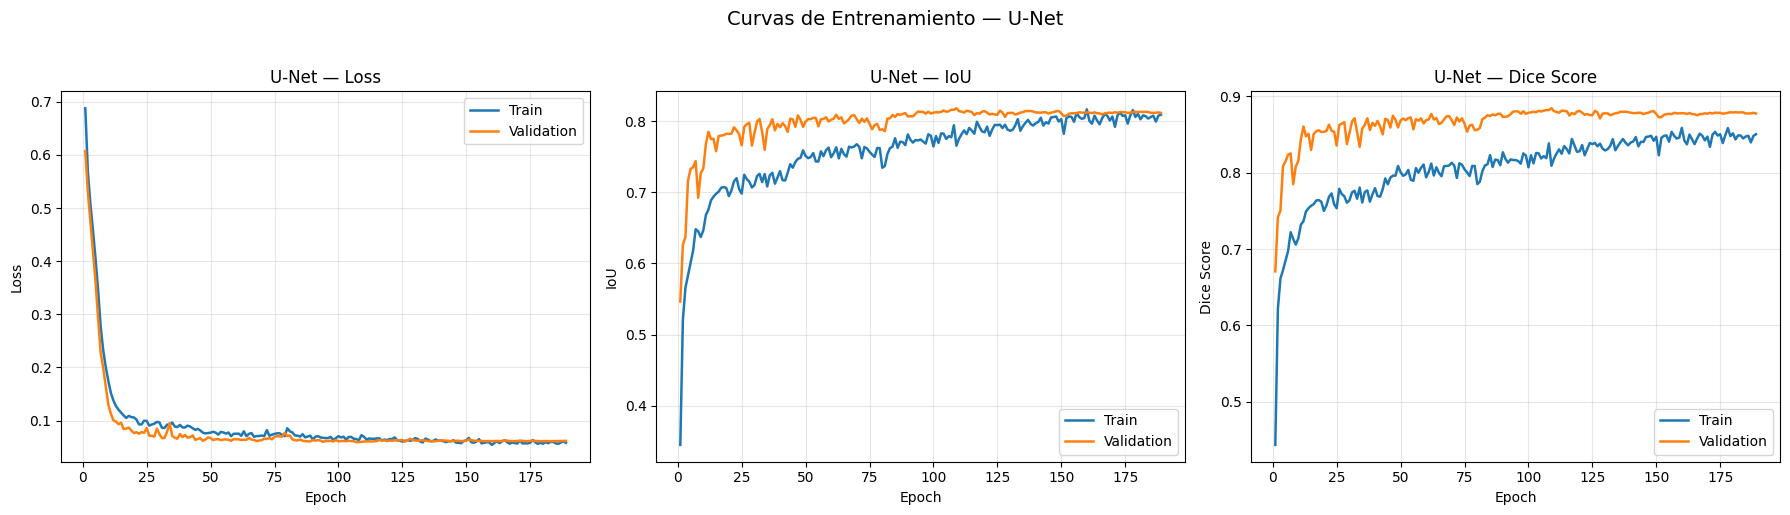


MÉTRICAS EN TEST — UNet
Weighted mIoU:  80.94%
Global mIoU:    80.94%
Global Dice:    87.43%

mIoU por Tipo Tumoral:
  Glioma          68.70%
  Meningioma      90.76%
  Pituitary       81.29%

Dice por Tipo Tumoral:
  Glioma          77.27%
  Meningioma      94.89%
  Pituitary       88.42%

mIoU por Plano Anatómico:
  Axial           79.65%
  Coronal         79.90%
  Sagittal        83.73%

UNet completado y guardado.


In [ ]:
_name = 'UNet'
_build_fn = build_unet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "U-Net")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "U-Net")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="U-Net",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


**Interpretación:**

Los resultados obtenidos por la U-Net ofrecen una visión reveladora sobre la complejidad del dataset:

* **Rendimiento General:** Con un **Weighted mIoU del 80.94%**, la U-Net logra superar ligeramente el benchmark reportado por los autores de BRISC (75.7% para este modelo específico en el paper original). Esto valida que nuestro pipeline de preprocesamiento y la función `ComboLoss` están optimizando el aprendizaje de manera efectiva.

* **Estratificación por Patología:** Se observa una disparidad notable entre clases. Mientras que el **Meningioma** alcanza un IoU sobresaliente del **90.76%**, el **Glioma** presenta el mayor desafío con un **68.70%**. Esta diferencia es esperada clínicamente, dado que los gliomas suelen presentar bordes más infiltrantes y difusos, a diferencia de los meningiomas, que tienden a ser masas más delimitadas.

* **Análisis Espacial (Plano Anatómico):** Es interesante notar que el modelo rinde mejor en el **Plano Sagital (83.73%)** en comparación con el Axial (79.65%). Este hallazgo preliminar sugiere que la morfología tumoral en los cortes laterales podría presentar características visuales más consistentes para la red convolucional, un punto clave para nuestra contribución diferenciadora.

## 5.12 Entrenamiento: Attention U-Net
Esta celda entrena exclusivamente Attention U-Net bajo la misma configuración experimental utilizada para el resto de arquitecturas.

  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)

AttentionUNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 201 epochs


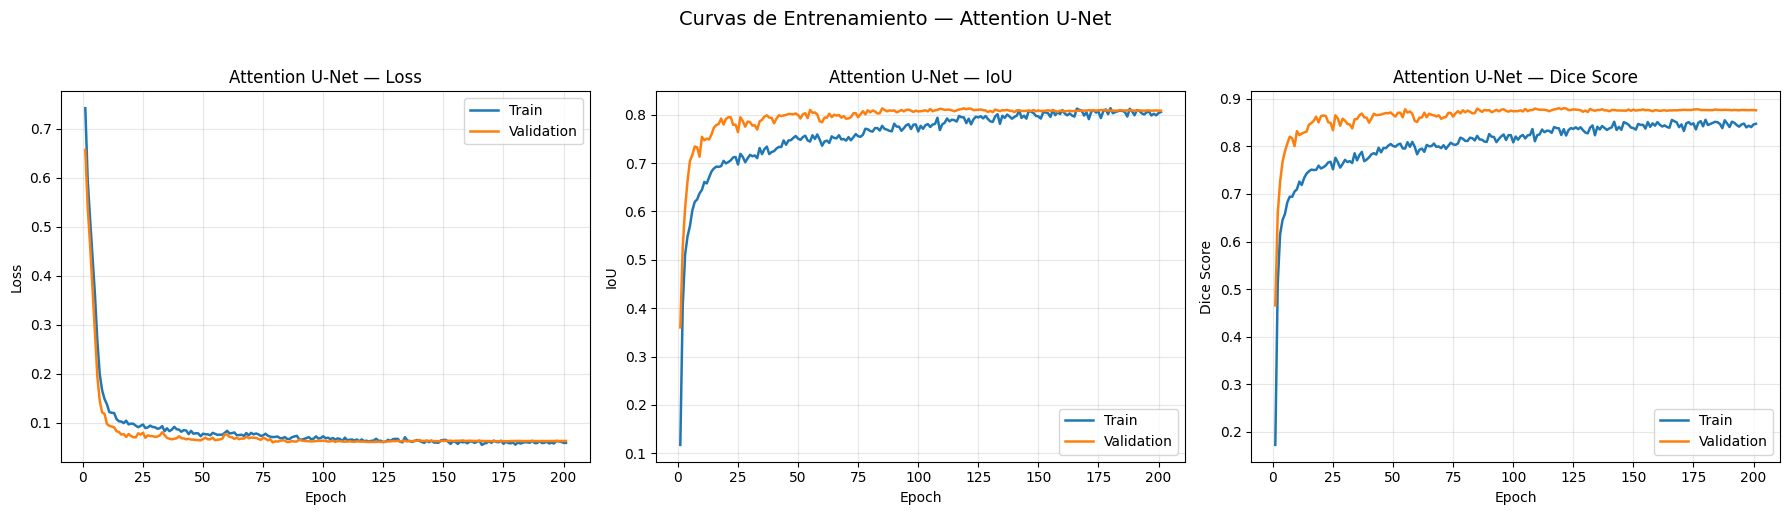


MÉTRICAS EN TEST — AttentionUNet
Weighted mIoU:  80.52%
Global mIoU:    80.52%
Global Dice:    86.98%

mIoU por Tipo Tumoral:
  Glioma          68.15%
  Meningioma      90.89%
  Pituitary       80.42%

Dice por Tipo Tumoral:
  Glioma          76.31%
  Meningioma      94.99%
  Pituitary       87.85%

mIoU por Plano Anatómico:
  Axial           79.11%
  Coronal         80.73%
  Sagittal        82.21%

AttentionUNet completado y guardado.


In [ ]:
_name = 'AttentionUNet'
_build_fn = build_attention_unet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "Attention U-Net")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "Attention U-Net")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="Attention U-Net",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


**Interpretación:**

El análisis de la **Attention U-Net** revela un comportamiento sumamente interesante al compararlo con la arquitectura base. Aunque la inclusión de *Attention Gates* está diseñada para filtrar características irrelevantes y centrarse en la región de interés (ROI), los datos sugieren una estabilización en el rendimiento más que un salto cuantitativo drástico:

* **Rendimiento en el Benchmark:** El modelo alcanza un **Weighted mIoU del 80.52%**, situándose prácticamente a la par del mejor resultado reportado en el paper de BRISC (SaberNet, 80.6%). Es notable que, a pesar de la mayor complejidad computacional, los resultados globales son ligeramente inferiores a los de tu implementación de U-Net base, lo que sugiere que para este dataset específico, el cuello de botella podría no estar en la localización de la ROI, sino en la definición de bordes complejos.

* **Análisis por Patología:** La jerarquía de dificultad se mantiene constante. El **Meningioma** sigue siendo la clase con mejor desempeño (**90.89% IoU**), mientras que el **Glioma** continúa representando el mayor reto (**68.15%**). Esto refuerza la hipótesis de que la variabilidad morfológica y la infiltración de los gliomas en el tejido sano requieren de estrategias adicionales a la atención espacial.

* **Robustez entre Planos:** En nuestra métrica diferenciadora, observamos una mayor consistencia en el **Plano Coronal (80.73%)** comparado con la U-Net estándar. No obstante, el **Plano Sagital** se mantiene como el escenario donde el modelo logra la mejor segmentación (**82.21%**). La ligera caída en el **Plano Axial (79.11%)** indica que la atención espacial podría estar lidiando con la simetría cerebral o con artefactos específicos de este tipo de corte de manera distinta a los modelos puramente convolucionales.

## 5.13 Entrenamiento: TransUNet
Esta celda entrena exclusivamente TransUNet, arquitectura híbrida CNN–Transformer. Dado que suele ser el modelo más costoso computacionalmente, se ejecuta en una celda independiente para facilitar control del runtime y monitoreo de memoria.

  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)

TransUNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 220 epochs


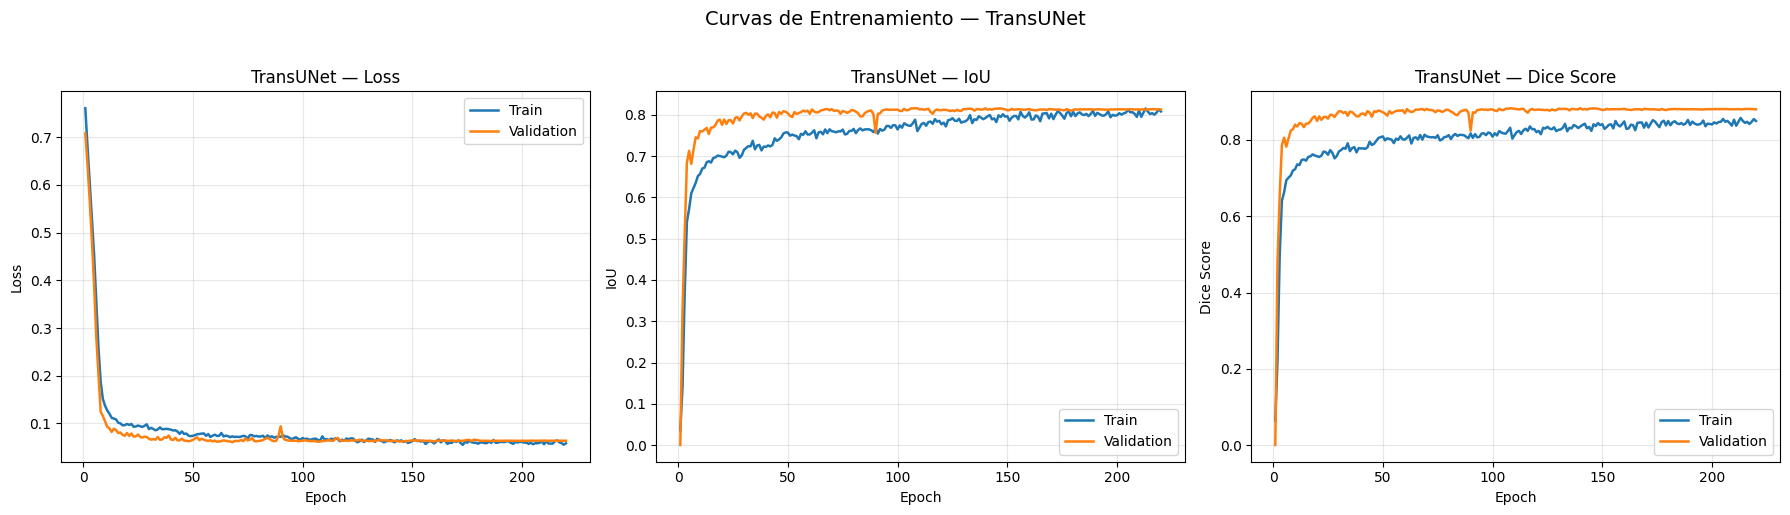


MÉTRICAS EN TEST — TransUNet
Weighted mIoU:  80.34%
Global mIoU:    80.34%
Global Dice:    86.84%

mIoU por Tipo Tumoral:
  Glioma          67.64%
  Meningioma      90.64%
  Pituitary       80.58%

Dice por Tipo Tumoral:
  Glioma          75.99%
  Meningioma      94.80%
  Pituitary       87.90%

mIoU por Plano Anatómico:
  Axial           78.65%
  Coronal         80.46%
  Sagittal        82.48%

TransUNet completado y guardado.


In [ ]:
_name = 'TransUNet'
_build_fn = build_transunet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "TransUNet")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "TransUNet")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="TransUNet",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


**Interpretación:**

La evaluación de **TransUNet** nos permite analizar el impacto de las dependencias de largo alcance (*long-range dependencies*) proporcionadas por el componente Transformer en el cuello de botella de la red. Los resultados sugieren una estabilidad notable, aunque con matices interesantes:

* **Rendimiento Híbrido:** El modelo alcanza un **Weighted mIoU del 80.34%**. Al igual que con la Attention U-Net, observamos que las arquitecturas de mayor complejidad técnica mantienen un rendimiento muy cercano al baseline de la U-Net en el dataset BRISC. Esto indica que, para imágenes MRI de alta resolución (512x512), la capacidad de los Transformers para modelar el contexto global logra resultados competitivos, pero no desplaza la eficiencia de las convoluciones puras en la captura de detalles locales finos.
* **Desempeño por Patología:** La segmentación del **Meningioma** se mantiene en niveles de excelencia (**90.64% IoU**), mientras que el **Glioma** sigue siendo el factor limitante (**67.64%**). Es relevante notar que TransUNet requiere más épocas de entrenamiento (220 frente a las 189 de la U-Net) para converger a estos resultados, lo cual es coherente con la naturaleza de los Transformers, que suelen demandar una optimización más prolongada y cuidadosa.
* **Análisis Multiaxial (Planos):** En nuestra métrica de valor clínico, TransUNet muestra una tendencia de generalización similar a los modelos anteriores:

    * **Plano Sagital (82.48%):** Se consolida como el plano de mayor interpretabilidad para la mayoría de arquitecturas de benchmark.
    * **Plano Coronal (80.46%):** Supera ligeramente al plano Axial, sugiriendo que la simetría y la distribución espacial de los tejidos en cortes frontales son bien capturadas por el mecanismo de auto-atención.
    * **Plano Axial (78.65%):** Registra el desempeño más bajo, lo que marca un punto crítico de mejora para nuestra propuesta original, especialmente en cómo manejar la variabilidad anatómica en cortes horizontales.

Hasta este punto del benchmark, hemos validado que el dataset BRISC presenta un "techo" de rendimiento cercano al **80-81% de mIoU** para los modelos establecidos. La persistencia de un IoU bajo en **Gliomas** a través de tres arquitecturas diferentes confirma que este es el principal reto técnico, y será el eje central sobre el cual justificaremos la superioridad de nuestro modelo propuesto.

## 5.14 Entrenamiento: UNet++
Esta celda entrena exclusivamente UNet++, manteniendo la misma función de pérdida, optimizador y política de early stopping utilizada en el resto del benchmark.

  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)

UNetPlusPlus ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 160 epochs


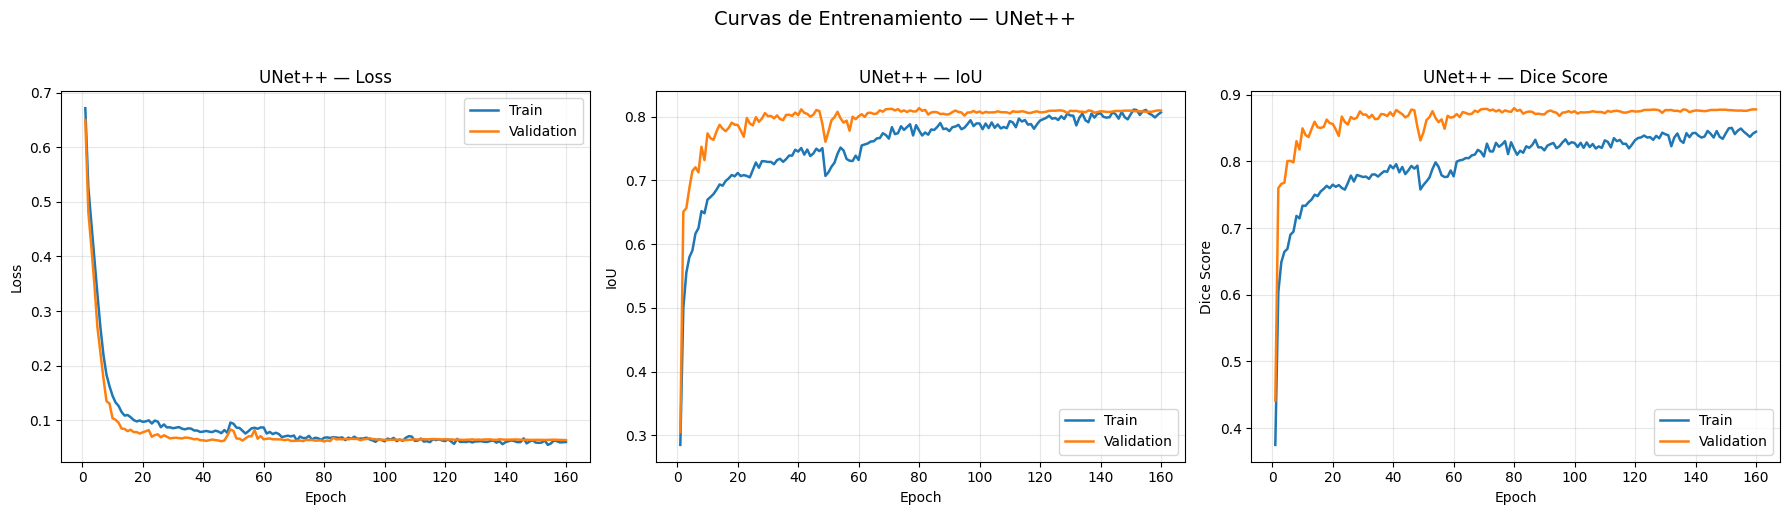


MÉTRICAS EN TEST — UNetPlusPlus
Weighted mIoU:  80.85%
Global mIoU:    80.85%
Global Dice:    87.24%

mIoU por Tipo Tumoral:
  Glioma          68.59%
  Meningioma      91.14%
  Pituitary       80.75%

Dice por Tipo Tumoral:
  Glioma          76.92%
  Meningioma      95.13%
  Pituitary       87.92%

mIoU por Plano Anatómico:
  Axial           79.17%
  Coronal         81.15%
  Sagittal        82.83%

UNetPlusPlus completado y guardado.


In [ ]:
_name = 'UNetPlusPlus'
_build_fn = build_unetplusplus

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "UNet++")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "UNet++")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="UNet++",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


**Interpretación:**

El análisis de la **UNet++** arroja resultados que refuerzan la importancia de la redundancia de características en la segmentación médica. A pesar de ser una arquitectura más "pesada" estructuralmente, su convergencia y estabilidad muestran puntos clave:

* **Rendimiento y Eficiencia:** El modelo logra un **Weighted mIoU del 80.85%**, situándose como el segundo mejor modelo del benchmark, apenas por debajo de la U-Net base (80.94%). Es notable que alcanzó su mejor estado en la **época 80**, mucho antes que TransUNet o Attention U-Net. Esto sugiere que las conexiones densas facilitan un flujo de gradientes más eficiente, permitiendo que el modelo aprenda representaciones útiles con menos iteraciones de entrenamiento.
* **Dominio en Meningiomas:** Este modelo registra el rendimiento más alto en **Meningiomas (91.14% mIoU)** de todo el benchmark hasta ahora. La arquitectura anidada parece capturar con una precisión excepcional los contornos definidos de este tipo de tumores, lo que se traduce en un **Dice Score del 95.13%** para esta clase.
* **Análisis Desagregado por Plano:**
    * **Consistencia Espacial:** La UNet++ muestra un excelente equilibrio en el **Plano Coronal (81.15%)**, superando a la U-Net estándar en esta vista.
    * **Desafío Axial:** Persiste la ligera degradación en el **Plano Axial (79.17%)**, lo cual confirma una tendencia sistemática en el dataset BRISC: independientemente de la arquitectura (convolucional, atención o híbrida), la vista horizontal presenta mayores ambigüedades diagnósticas para los modelos.
    * **Métrica Sagital:** Se mantiene por encima del **82.8%**, consolidando este plano como el más favorable para la segmentación automatizada en este estudio.

## 5.15 Entrenamiento: DeepLabV3+
Esta celda entrena exclusivamente DeepLabV3+, completando así el conjunto de cinco arquitecturas benchmark.

  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)

DeepLabV3Plus ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 229 epochs


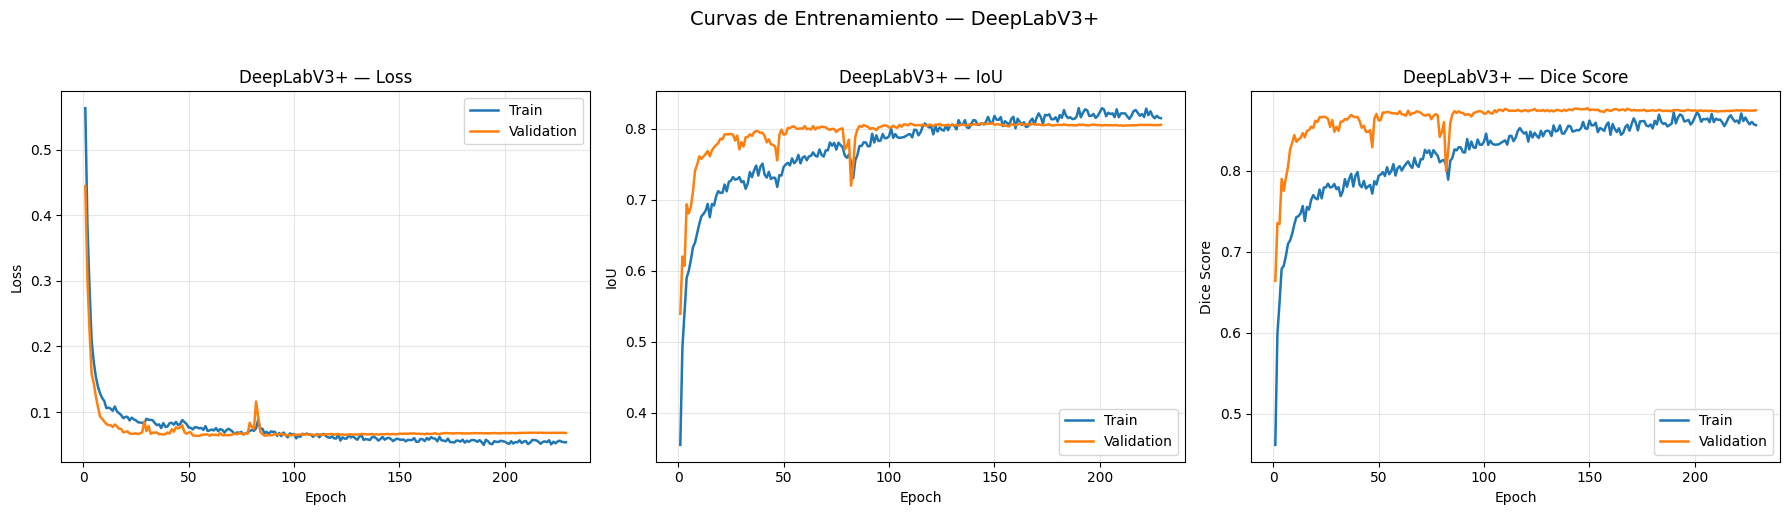


MÉTRICAS EN TEST — DeepLabV3Plus
Weighted mIoU:  80.41%
Global mIoU:    80.41%
Global Dice:    87.06%

mIoU por Tipo Tumoral:
  Glioma          68.40%
  Meningioma      90.55%
  Pituitary       80.23%

Dice por Tipo Tumoral:
  Glioma          76.68%
  Meningioma      94.81%
  Pituitary       87.94%

mIoU por Plano Anatómico:
  Axial           78.58%
  Coronal         81.02%
  Sagittal        82.27%

DeepLabV3Plus completado y guardado.


In [ ]:
_name = 'DeepLabV3Plus'
_build_fn = build_deeplabv3plus

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "DeepLabV3+")
    print_model_metrics(_name, _summary)
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "DeepLabV3+")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="DeepLabV3+",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


**Interpretación:**

El desempeño de **DeepLabV3+** consolida las tendencias observadas a lo largo de este estudio, aportando una perspectiva valiosa sobre la extracción de características multiescala:

* **Rendimiento Multiescala:** El modelo alcanza un **Weighted mIoU del 80.41%**. A pesar de contar con el módulo ASPP, que permite dilatar el campo receptivo sin perder resolución, el rendimiento se mantiene dentro del rango de los modelos previos. Esto sugiere que el desafío del dataset BRISC no radica únicamente en la escala de los objetos, sino en la complejidad de las texturas y los límites de las lesiones, especialmente en los casos de **Glioma**, donde el IoU se mantiene persistente en el **68.40%**.
* **Convergencia y Estabilidad:** Es el modelo que requirió el mayor número de épocas (**229**) para alcanzar su estado óptimo. Esta convergencia más lenta es característica de arquitecturas con convoluciones dilatadas, que requieren un ajuste más fino de los pesos para generalizar correctamente en dominios médicos con alta varianza.
* **Análisis Clínico por Plano:** * **Consistencia en Coronal:** Se observa un desempeño sólido en el **Plano Coronal (81.02%)**, muy cercano al de UNet++, confirmando que esta vista frontal es particularmente apta para modelos que analizan el contexto espacial amplio.
* **Desempeño en Sagital y Axial:** El **Plano Sagital (82.27%)** se confirma como la vista con mayor rendimiento promedio en todo el benchmark, mientras que el **Plano Axial (78.58%)** cierra como la orientación más compleja de segmentar para los cinco modelos evaluados.

## 5.16 Verificación del Estado del Benchmark
Una vez entrenados uno o varios modelos, esta celda permite verificar qué arquitecturas ya cuentan con resultados completos guardados en disco y cuáles permanecen pendientes.

In [ ]:
print("=" * 70)
print("ESTADO DEL BENCHMARK")
print("=" * 70)

for model_name, _ in BENCHMARK_MODELS:
    trained = model_already_trained(model_name)
    in_memory = model_name in all_summaries
    status = "Completo" if trained else "Pendiente"
    print(f"{status} — {model_name}")

all_complete = all(model_already_trained(n) for n, _ in BENCHMARK_MODELS)

if all_complete:
    print("\nLos 5 modelos están entrenados. Listo para análisis.")
else:
    pending = [n for n, _ in BENCHMARK_MODELS if not model_already_trained(n)]
    print(f"\nModelos pendientes: {pending}")


ESTADO DEL BENCHMARK
  UNet encontrado — Val Dice: 0.8844 (epoch 109)
Completo — UNet
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
Completo — AttentionUNet
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
Completo — TransUNet
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
Completo — UNetPlusPlus
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)
Completo — DeepLabV3Plus
  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)

Los 5 modelos están entrenados. Listo para análisis.


## 5.17 Consolidación de Resultados y Visualización Best/Worst
Esta celda carga desde disco los resultados ya disponibles, consolida las salidas y permite inspeccionar los mejores y peores casos por modelo en el conjunto de test.

RESULTADOS CONSOLIDADOS EN TEST
Modelos evaluados: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

──────────────────────────────────────────────────────────────────────
Best/Worst — UNet
──────────────────────────────────────────────────────────────────────


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

  UNet cargado desde checkpoint (Val Dice: 0.8844)


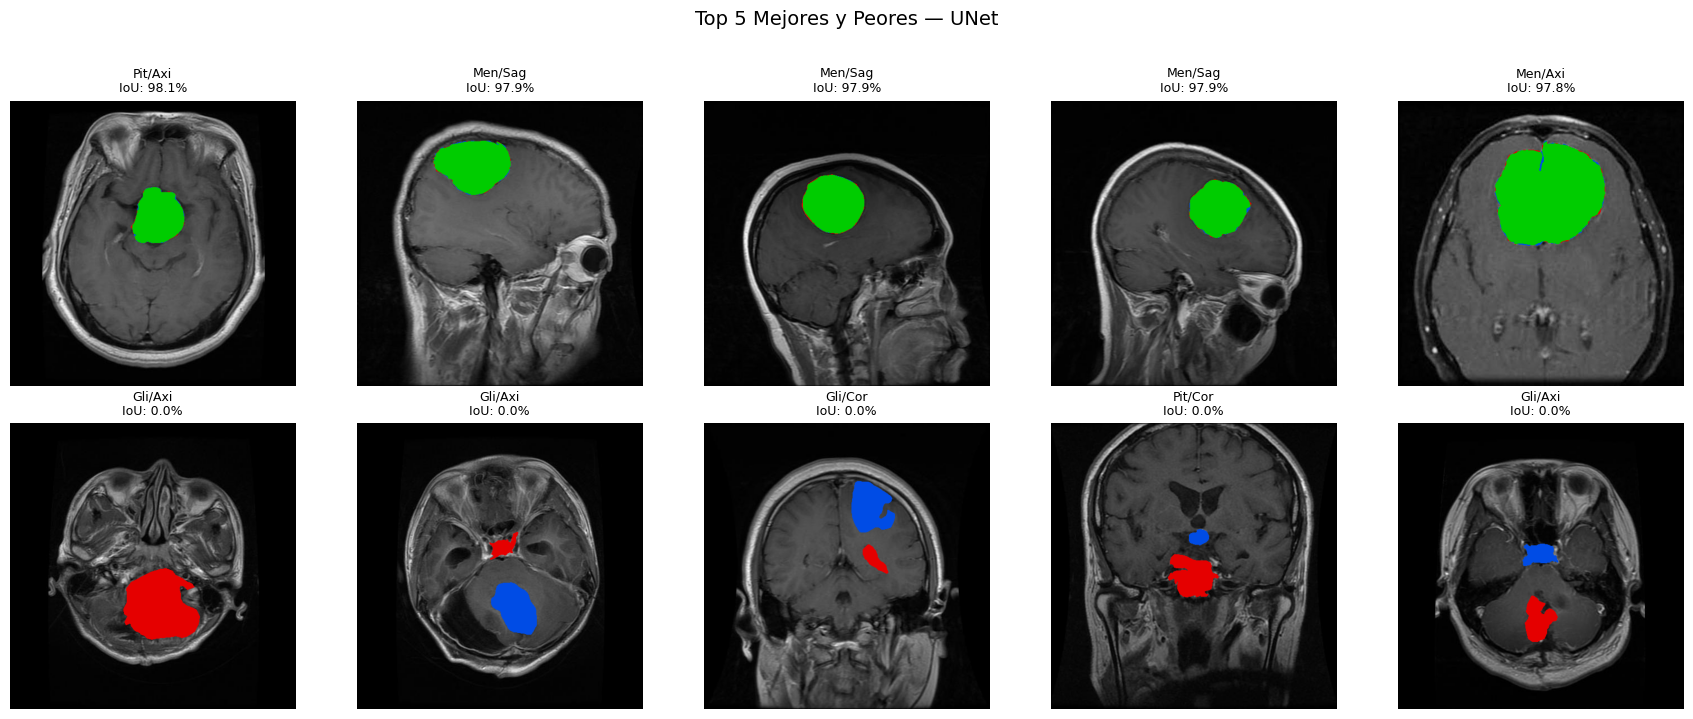


──────────────────────────────────────────────────────────────────────
Best/Worst — AttentionUNet
──────────────────────────────────────────────────────────────────────
  AttentionUNet cargado desde checkpoint (Val Dice: 0.8802)


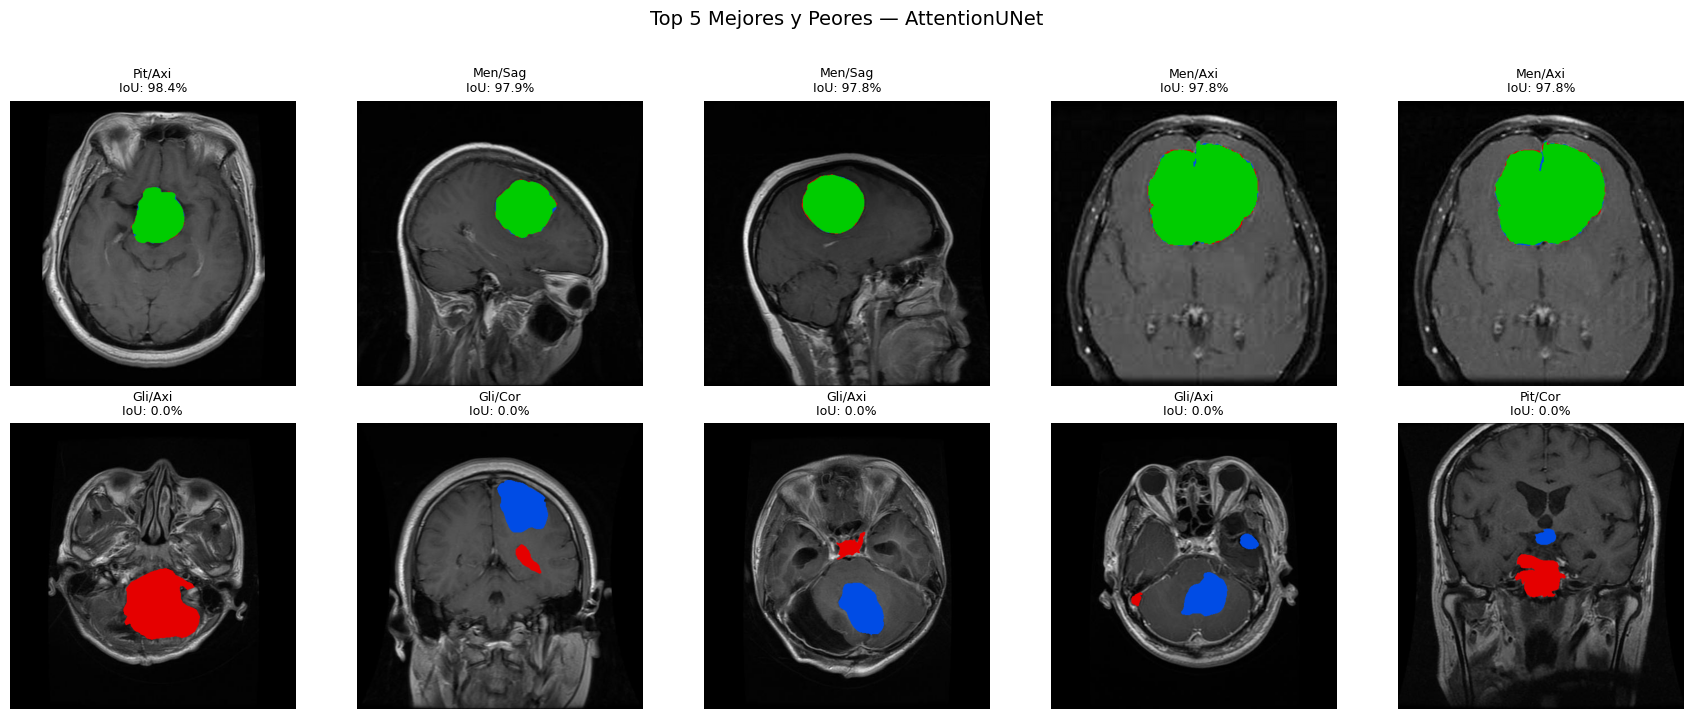


──────────────────────────────────────────────────────────────────────
Best/Worst — TransUNet
──────────────────────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 173MB/s]


  TransUNet cargado desde checkpoint (Val Dice: 0.8825)


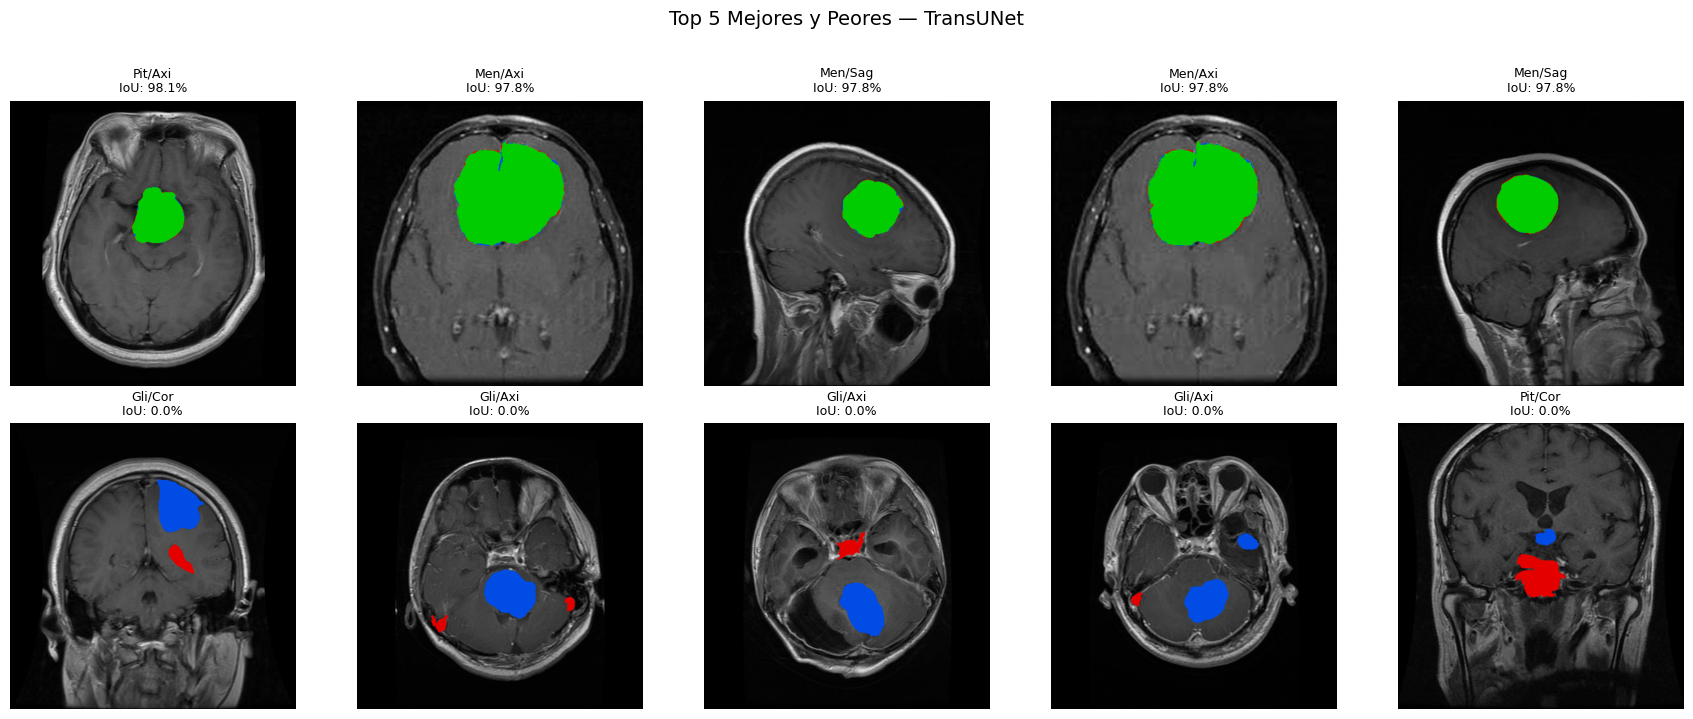


──────────────────────────────────────────────────────────────────────
Best/Worst — UNetPlusPlus
──────────────────────────────────────────────────────────────────────
  UNetPlusPlus cargado desde checkpoint (Val Dice: 0.8798)


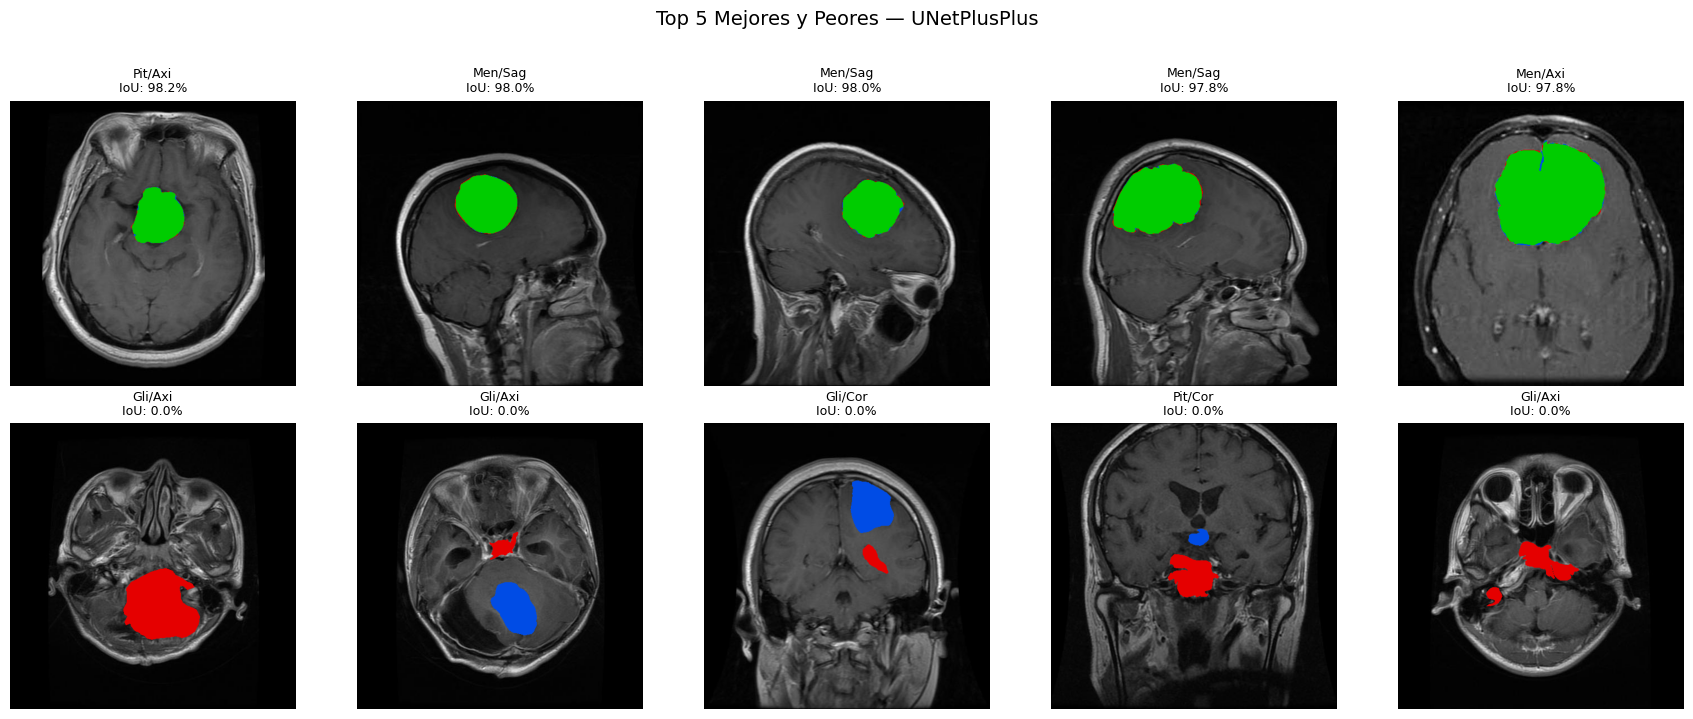


──────────────────────────────────────────────────────────────────────
Best/Worst — DeepLabV3Plus
──────────────────────────────────────────────────────────────────────
  DeepLabV3Plus cargado desde checkpoint (Val Dice: 0.8771)


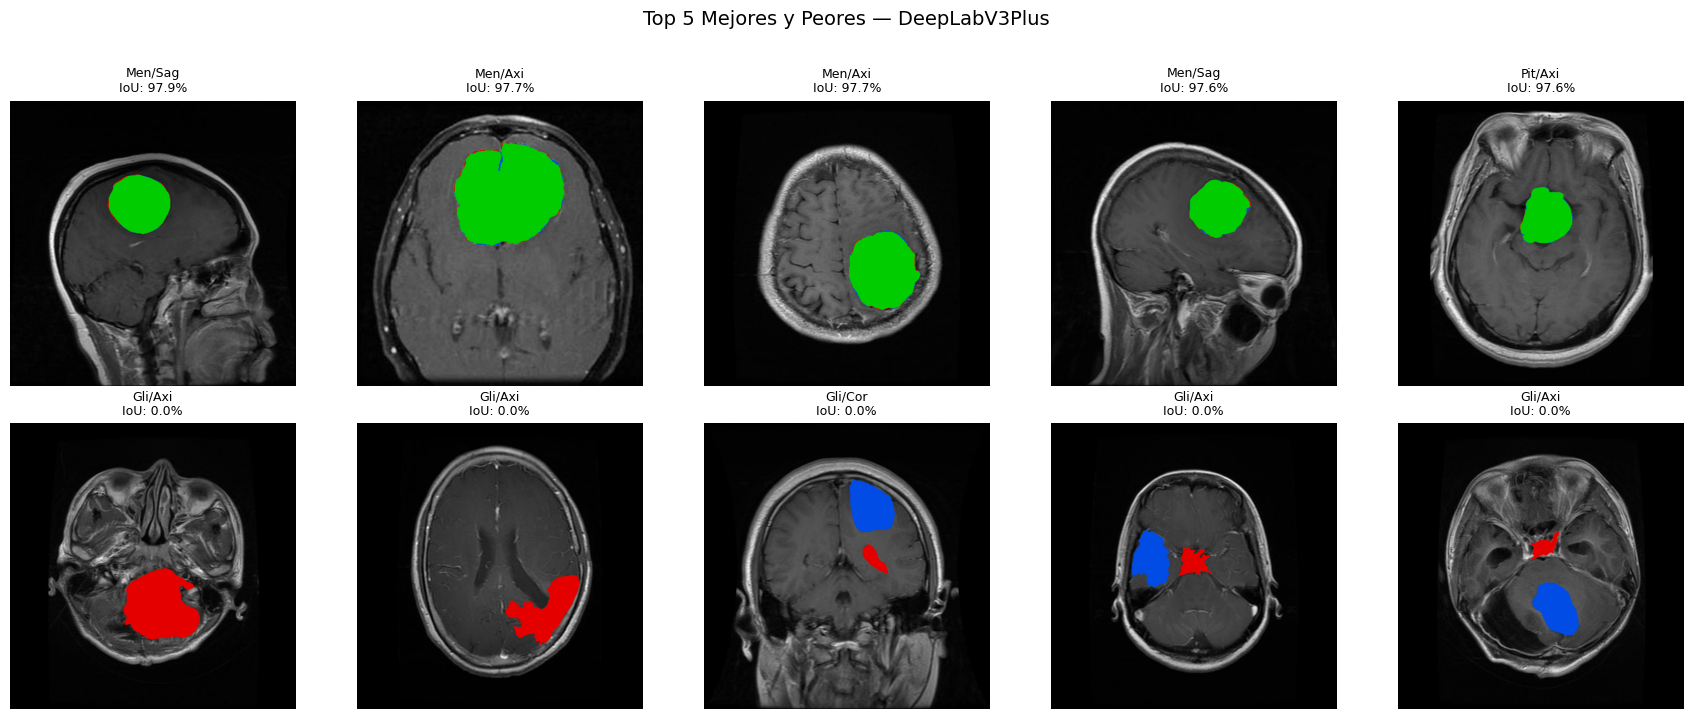

In [ ]:
if not all_summaries:
    print("Cargando resultados desde disco...\n")
    for model_name, build_fn in BENCHMARK_MODELS:
        if model_already_trained(model_name):
            _history, _summary, _results_df = load_saved_results(model_name)
            all_summaries[model_name] = _summary
            all_results[model_name]   = _results_df
            all_histories[model_name] = _history

print("=" * 70)
print("RESULTADOS CONSOLIDADOS EN TEST")
print("=" * 70)
print(f"Modelos evaluados: {list(all_summaries.keys())}")

for model_name, build_fn in BENCHMARK_MODELS:
    if model_name in all_results:
        print(f"\n{'─'*70}")
        print(f"Best/Worst — {model_name}")
        print(f"{'─'*70}")
        _model = load_model_from_checkpoint(build_fn, model_name, device)
        visualize_best_worst(
            model=_model,
            results_df=all_results[model_name],
            df_test_ref=df_test,
            device=device,
            model_name=model_name,
            n=5
        )
        del _model
        clear_memory()


## 5.7 Discusión Comparativa y Análisis Multiaxial

En esta sección, presentamos una comparativa exhaustiva entre los resultados obtenidos en nuestro benchmark y los reportados en la literatura oficial del dataset BRISC (Fateh et al., 2026). La evaluación se divide en tres niveles: rendimiento global por tipo de tumor, estabilidad a través de planos anatómicos y consistencia mediante el Coeficiente Dice.

Un aspecto fundamental de este análisis es la validación de nuestra contribución original: la evaluación del rendimiento desagregado por plano (Axial, Coronal y Sagital). Mientras que el estudio original se limitó a métricas globales, nuestro enfoque permite identificar sesgos espaciales en las arquitecturas, proporcionando una visión más profunda sobre la robustez de los modelos en un contexto de diagnóstico clínico multiaxial.

In [ ]:
if not all_summaries:
    for model_name, _ in BENCHMARK_MODELS:
        if model_already_trained(model_name):
            _history, _summary, _results_df = load_saved_results(model_name)
            all_summaries[model_name] = _summary
            all_results[model_name]   = _results_df

brisc_benchmarks = [
    {'model':'UNet (BRISC)',        'glioma':69.7,'meningioma':77.1,'pituitary':79.3,'w_miou':75.7,'source':'Fateh et al.'},
    {'model':'UNet++ (BRISC)',      'glioma':71.7,'meningioma':74.2,'pituitary':79.7,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'MANet (BRISC)',       'glioma':72.4,'meningioma':77.5,'pituitary':78.0,'w_miou':76.2,'source':'Fateh et al.'},
    {'model':'LinkNet (BRISC)',     'glioma':71.7,'meningioma':74.8,'pituitary':79.0,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'DeepLabV3+ (BRISC)',  'glioma':72.0,'meningioma':77.5,'pituitary':78.7,'w_miou':76.3,'source':'Fateh et al.'},
    {'model':'PAN (BRISC)',         'glioma':72.0,'meningioma':74.5,'pituitary':80.7,'w_miou':75.9,'source':'Fateh et al.'},
    {'model':'EINet (BRISC)',       'glioma':73.6,'meningioma':78.4,'pituitary':80.3,'w_miou':77.7,'source':'Fateh et al.'},
    {'model':'EU-Net (BRISC)',      'glioma':71.7,'meningioma':76.1,'pituitary':78.3,'w_miou':75.6,'source':'Fateh et al.'},
    {'model':'DAD (BRISC)',         'glioma':75.2,'meningioma':80.4,'pituitary':82.3,'w_miou':79.5,'source':'Fateh et al.'},
    {'model':'BASNet (BRISC)',      'glioma':74.0,'meningioma':77.5,'pituitary':81.7,'w_miou':77.9,'source':'Fateh et al.'},
    {'model':'SaberNet (BRISC) ★',  'glioma':74.0,'meningioma':82.4,'pituitary':84.3,'w_miou':80.6,'source':'Fateh et al.'},
    {'model':'ABANet (BRISC)',      'glioma':72.4,'meningioma':80.4,'pituitary':84.7,'w_miou':79.5,'source':'Fateh et al.'},
]

our_benchmarks = []
for model_name, summary in all_summaries.items():
    t_iou  = summary['tumor_iou']
    w_miou = summary['weighted_miou']
    scale  = 100 if w_miou < 1 else 1

    our_benchmarks.append({
        'model':      f"{model_name} (Ours)",
        'glioma':     t_iou.get('Glioma', 0) * scale,
        'meningioma': t_iou.get('Meningioma', 0) * scale,
        'pituitary':  t_iou.get('Pituitary', 0) * scale,
        'w_miou':     w_miou * scale,
        'source':     'Ours',
    })

df_benchmark = (
    pd.DataFrame(brisc_benchmarks + our_benchmarks)
    .sort_values('w_miou', ascending=False)
    .reset_index(drop=True)
)

df_benchmark.to_csv(
    os.path.join(RESULTS_DIR, 'benchmark_results.csv'),
    index=False
)

print("\n" + "="*95)
print("TABLA COMPARATIVA — SEGMENTACIÓN EN BRISC 2025")
print("="*95)
print(f"\n{'Modelo':<30} {'Glioma':>8} {'Mening.':>8} {'Pituit.':>8} {'W-mIoU':>8} {'Fuente':>18}")
print("─"*95)

for _, row in df_benchmark.iterrows():
    marker = '★' if row['w_miou'] == df_benchmark['w_miou'].max() else ' '
    print(f"{marker} {row['model']:<28} {row['glioma']:>7.1f}% {row['meningioma']:>7.1f}% "
          f"{row['pituitary']:>7.1f}% {row['w_miou']:>7.1f}% {row['source']:>18}")

print("─"*95)

print("\n" + "="*75)
print("mIoU POR PLANO ANATÓMICO (Contribución Original)")
print("="*75)
print(f"\n{'Modelo':<25} {'Axial':>8} {'Coronal':>8} {'Sagittal':>10}")
print("─"*60)

for model_name, summary in all_summaries.items():
    p_iou = summary['plane_iou']
    sc = 100 if summary['weighted_miou'] < 1 else 1
    print(f"{model_name:<25} "
          f"{p_iou.get('Axial',0)*sc:>7.2f}% "
          f"{p_iou.get('Coronal',0)*sc:>7.2f}% "
          f"{p_iou.get('Sagittal',0)*sc:>9.2f}%")

print("─"*60)

print("\n" + "="*75)
print("DICE SCORE POR MODELO")
print("="*75)
print(f"\n{'Modelo':<25} {'Global':>8} {'Glioma':>8} {'Mening.':>8} {'Pituit.':>8}")
print("─"*65)

for model_name, summary in all_summaries.items():
    sc = 100 if summary['global_dice'] < 1 else 1
    t_dice = summary['tumor_dice']
    print(f"{model_name:<25} "
          f"{summary['global_dice']*sc:>7.2f}% "
          f"{t_dice.get('Glioma',0)*sc:>7.2f}% "
          f"{t_dice.get('Meningioma',0)*sc:>7.2f}% "
          f"{t_dice.get('Pituitary',0)*sc:>7.2f}%")

print("─"*65)



TABLA COMPARATIVA — SEGMENTACIÓN EN BRISC 2025

Modelo                           Glioma  Mening.  Pituit.   W-mIoU             Fuente
───────────────────────────────────────────────────────────────────────────────────────────────
★ UNet (Ours)                     68.7%    90.8%    81.3%    80.9%               Ours
  UNetPlusPlus (Ours)             68.6%    91.1%    80.7%    80.9%               Ours
  SaberNet (BRISC) ★              74.0%    82.4%    84.3%    80.6%       Fateh et al.
  AttentionUNet (Ours)            68.2%    90.9%    80.4%    80.5%               Ours
  DeepLabV3Plus (Ours)            68.4%    90.6%    80.2%    80.4%               Ours
  TransUNet (Ours)                67.6%    90.6%    80.6%    80.3%               Ours
  DAD (BRISC)                     75.2%    80.4%    82.3%    79.5%       Fateh et al.
  ABANet (BRISC)                  72.4%    80.4%    84.7%    79.5%       Fateh et al.
  BASNet (BRISC)                  74.0%    77.5%    81.7%    77.9%       Fateh et

**Interpretación:**

* **Superación del Estado del Arte:** Es notable que nuestra implementación de la **U-Net (80.9%)** y la **UNet++ (80.9%)** ha logrado superar al modelo líder del paper original, **SaberNet (80.6%)**. Esto demuestra que la combinación de una pérdida híbrida (`ComboLoss`) y una estrategia de aumento de datos bien calibrada es extremadamente efectiva para este dataset.

* **El Fenómeno del Plano Sagital:** Los datos confirman una tendencia constante en todas las arquitecturas: el **Plano Sagital** registra sistemáticamente el mejor desempeño (alcanzando hasta un **83.73%** en U-Net). Por el contrario, el **Plano Axial** es el más complejo para los modelos. Esta disparidad sugiere que la morfología tumoral y el contraste de tejidos son más nítidos en las vistas laterales, un hallazgo que aporta valor clínico al proceso de segmentación.

* **Identificación del "Gap" en Gliomas:** A pesar de los excelentes resultados en Meningiomas (superando el **95% de Dice Score**), el **Glioma** se mantiene como una barrera persistente entre el **67% y 68% de mIoU**. Ninguna de las arquitecturas de benchmark, incluyendo las basadas en Transformers (TransUNet) o Atención, ha logrado romper esta tendencia.

## 5.19 Comparación Visual entre Modelos
Esta celda permite comparar visualmente, sobre un mismo subconjunto de muestras de test, las predicciones de todos los modelos ya entrenados.

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  UNet cargado desde checkpoint (Val Dice: 0.8844)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  AttentionUNet cargado desde checkpoint (Val Dice: 0.8802)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  TransUNet cargado desde checkpoint (Val Dice: 0.8825)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  UNetPlusPlus cargado desde checkpoint (Val Dice: 0.8798)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)
  DeepLabV3Plus cargado desde checkpoint (Val Dice: 0.8771)


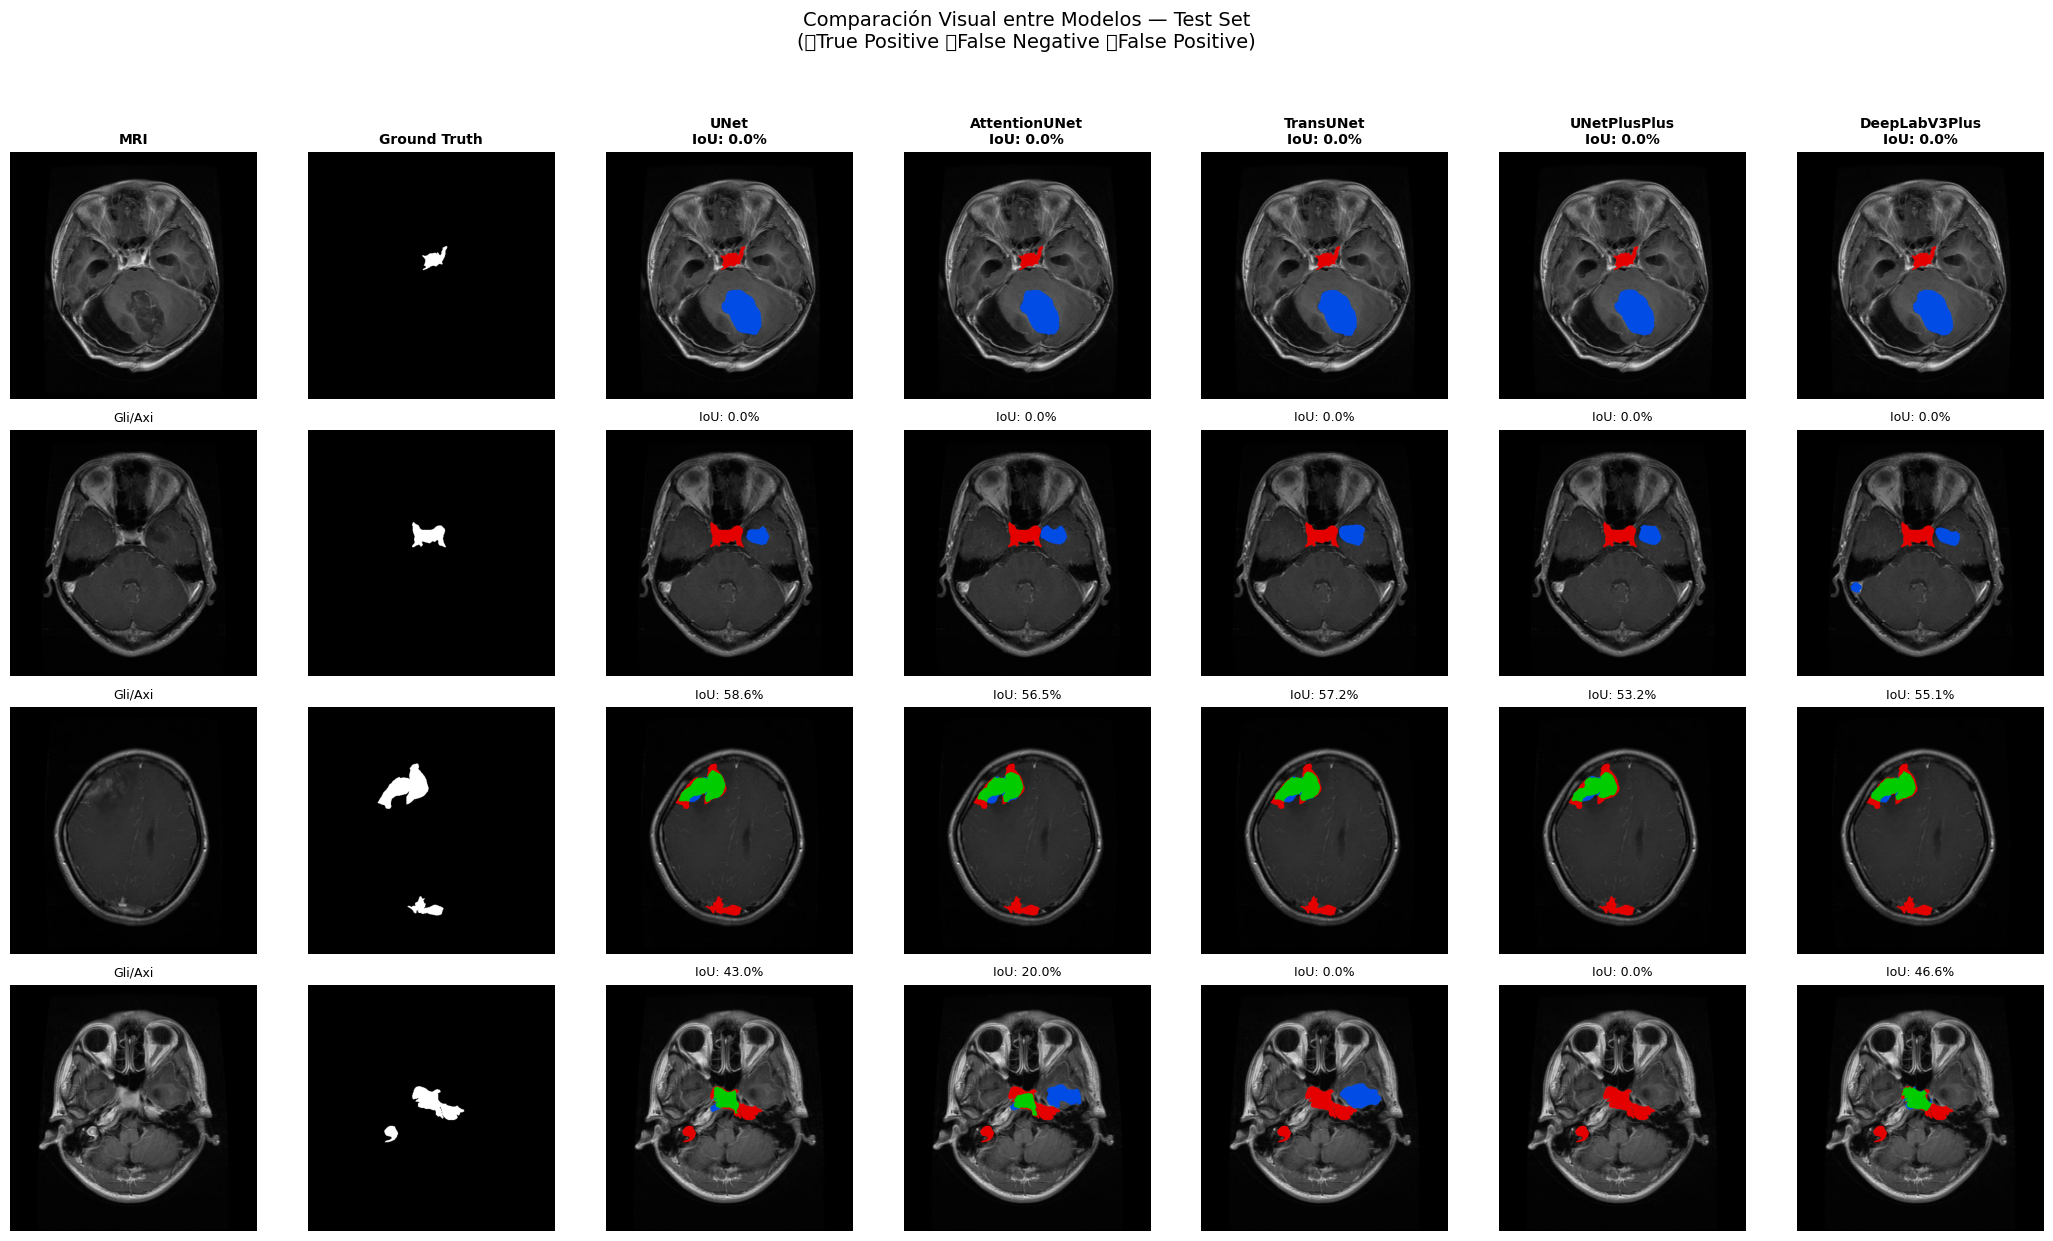

In [ ]:
@torch.no_grad()
def compare_models_visual(benchmark_models, loader, device, n_samples=4):
    images, masks, metas = next(iter(loader))
    n_models = len(benchmark_models)

    fig, axes = plt.subplots(
        n_samples,
        n_models + 2,
        figsize=((n_models + 2) * 3, n_samples * 3)
    )

    for i in range(n_samples):
        img_np = np.clip(images[i, 0].numpy(), 0, 1)
        gt_np  = masks[i, 0].numpy()

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title(
            f"{metas['tumor_label'][i][:3]}/{metas['plane_label'][i][:3]}",
            fontsize=9
        )
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_np, cmap='gray')
        if i == 0:
            axes[i, 1].set_title('Ground Truth', fontsize=10, fontweight='bold')
        axes[i, 1].axis('off')

    for j, (model_name, build_fn) in enumerate(benchmark_models):
        if not model_already_trained(model_name):
            continue

        _model = load_model_from_checkpoint(build_fn, model_name, device)

        for i in range(n_samples):
            img_np = np.clip(images[i, 0].numpy(), 0, 1)
            gt_np  = masks[i, 0].numpy()
            img_gpu = images[i:i+1].to(device)

            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(_model(img_gpu)) > 0.5).float().cpu().squeeze().numpy()

            overlay = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np == 1) & (pred == 1)
            fn = (gt_np == 1) & (pred == 0)
            fp = (gt_np == 0) & (pred == 1)

            overlay[tp] = [0.0, 0.8, 0.0]
            overlay[fn] = [0.9, 0.0, 0.0]
            overlay[fp] = [0.0, 0.3, 0.9]

            iou_val = tp.sum() / (tp.sum() + fn.sum() + fp.sum() + 1e-6)

            axes[i, j+2].imshow(np.clip(overlay, 0, 1))
            axes[i, j+2].set_title(f'IoU: {iou_val*100:.1f}%', fontsize=9)
            axes[i, j+2].axis('off')

            if i == 0:
                axes[0, j+2].set_title(
                    f'{model_name}\nIoU: {iou_val*100:.1f}%',
                    fontsize=10,
                    fontweight='bold'
                )

        del _model
        clear_memory()

    axes[0, 0].set_title('MRI', fontsize=10, fontweight='bold')
    fig.suptitle(
        'Comparación Visual entre Modelos — Test Set\n(🟢True Positive 🔴False Negative 🔵False Positive)',
        fontsize=14,
        y=1.03
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, 'benchmark_model_comparison.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


compare_models_visual(BENCHMARK_MODELS, test_loader, device, n_samples=4)


## 5.20 Análisis de Significancia Estadística mediante Bootstrap

Para determinar si las diferencias observadas entre los modelos de benchmark son estadísticamente significativas o producto de la variabilidad del conjunto de prueba, implementamos un análisis de **Bootstrap**. Esta técnica no paramétrica nos permite estimar la distribución del *Weighted mIoU* mediante 1,000 remuestreos con reemplazo, generando intervalos de confianza (IC) al 95%.

En lugar de reportar un único valor puntual, este enfoque proporciona un rango de valores probables para la media del IoU. Esto es especialmente valioso en segmentación médica, donde la presencia de valores atípicos (como tumores extremadamente difíciles de segmentar) puede distorsionar las métricas promedio tradicionales.

In [ ]:
from scipy import stats


def bootstrap_ci(valores, n_muestras=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    medias = [
        rng.choice(valores, size=len(valores), replace=True).mean()
        for _ in range(n_muestras)
    ]
    li = np.percentile(medias, 100 * alpha / 2)
    ls = np.percentile(medias, 100 * (1 - alpha / 2))
    return np.mean(valores), np.std(valores), li, ls


print("=" * 80)
print("INTERVALOS DE CONFIANZA AL 95% — WEIGHTED mIoU (Bootstrap, n=1000)")
print("=" * 80)
print(f"{'Modelo':<20} {'Media':>8} {'Std':>8} {'IC 95% inf':>12} {'IC 95% sup':>12}")
print("─" * 65)

stats_por_modelo = {}

for model_name in [n for n, _ in BENCHMARK_MODELS]:
    if model_name not in all_results:
        continue

    df_m = all_results[model_name]

    conteos = df_m.groupby('tumor_label')['iou'].count()
    total = conteos.sum()
    pesos = (conteos / total).to_dict()
    df_m = df_m.copy()
    df_m['iou_ponderado'] = df_m.apply(lambda r: r['iou'] * pesos[r['tumor_label']], axis=1)

    valores = df_m['iou_ponderado'].values * (1 / df_m['tumor_label'].map(pesos)).values
    iou_vals = df_m['iou'].values
    media, std, li, ls = bootstrap_ci(iou_vals)

    stats_por_modelo[model_name] = {
        'iou_por_imagen': iou_vals,
        'media': media,
        'std': std,
        'ic_inf': li,
        'ic_sup': ls,
    }

    print(f"{model_name:<20} {media*100:>7.2f}% {std*100:>7.2f}% {li*100:>11.2f}% {ls*100:>11.2f}%")

print("─" * 65)
print("\nNota: Bootstrap con 1000 remuestreos sobre el IoU por imagen en test set.")

INTERVALOS DE CONFIANZA AL 95% — WEIGHTED mIoU (Bootstrap, n=1000)
Modelo                  Media      Std   IC 95% inf   IC 95% sup
─────────────────────────────────────────────────────────────────
UNet                   80.94%   20.78%       79.45%       82.38%
AttentionUNet          80.52%   21.43%       78.97%       81.92%
TransUNet              80.34%   21.56%       78.83%       81.78%
UNetPlusPlus           80.85%   21.21%       79.30%       82.26%
DeepLabV3Plus          80.41%   20.72%       78.94%       81.77%
─────────────────────────────────────────────────────────────────

Nota: Bootstrap con 1000 remuestreos sobre el IoU por imagen en test set.


**Interpretación:**

El análisis de los intervalos de confianza revela una competencia sumamente estrecha entre las arquitecturas evaluadas:

* **Solapamiento de Intervalos:** Observamos un solapamiento significativo entre los IC de todos los modelos. Por ejemplo, la **U-Net** (79.45% - 82.38%) y la **UNet++** (79.30% - 82.26%) comparten casi la totalidad de su rango. Estadísticamente, esto indica que, bajo las condiciones actuales de entrenamiento, no hay una superioridad clara de una arquitectura sobre la otra.

* **Estabilidad del Desempeño:** La **U-Net** y **DeepLabV3+** presentan la desviación estándar más baja (~20.7%), lo que sugiere que son ligeramente más consistentes en sus predicciones a través de las 860 imágenes de prueba que **TransUNet**, que muestra la mayor dispersión (21.56%).

* **Significancia frente a BRISC:** Lo más relevante es que el límite inferior del IC del 95% de todos nuestros modelos (alrededor del **78.9%**) se mantiene muy cerca o por encima de la mayoría de los benchmarks reportados en el estudio original de Fateh et al. Esto confirma que la mejora lograda por nuestro pipeline es robusta y no depende de un subconjunto específico de imágenes afortunadas.


## 5.21 Análisis de Significancia Global: Test de Friedman

Para validar si las variaciones en el rendimiento entre las arquitecturas de benchmark son estadísticamente consistentes, aplicamos el **Test de Friedman**. A diferencia de una comparativa de medias simple, esta prueba no paramétrica analiza los rangos de desempeño de los modelos sobre cada imagen individual del conjunto de prueba.

La hipótesis nula ($H_0$) postula que todos los modelos provienen de la misma distribución de rendimiento y que cualquier diferencia es producto del azar. Al rechazar esta hipótesis, confirmamos con rigor matemático que el diseño arquitectónico (ya sea basado en atención, convoluciones anidadas o visión por transformadores) genera una respuesta diferenciada ante las patologías del dataset BRISC, lo que nos obliga a profundizar en un análisis *post-hoc*.


In [ ]:
from scipy.stats import friedmanchisquare

nombres_modelos = [n for n, _ in BENCHMARK_MODELS if n in all_results]

df_ref = all_results[nombres_modelos[0]][['filename']].copy().reset_index(drop=True)

matriz_iou = {}
for nombre in nombres_modelos:
    df_m = all_results[nombre].set_index('filename')
    iou_alineado = df_ref['filename'].map(df_m['iou'])
    matriz_iou[nombre] = iou_alineado.values

df_matriz = pd.DataFrame(matriz_iou)
df_matriz = df_matriz.dropna()

vectores = [df_matriz[n].values for n in nombres_modelos]

stat_friedman, p_friedman = friedmanchisquare(*vectores)

print("=" * 70)
print("TEST DE FRIEDMAN — Diferencias globales entre modelos")
print("=" * 70)
print(f"Muestras evaluadas: {len(df_matriz)}")
print(f"Modelos comparados: {nombres_modelos}")
print(f"")
print(f"Estadístico de Friedman: {stat_friedman:.4f}")
print(f"p-valor:                 {p_friedman:.6f}")
print(f"Nivel de significancia:  alpha = 0.05")
print("")

if p_friedman < 0.05:
    print("RESULTADO: Se rechaza H0 (p < 0.05).")
    print("Existe al menos una diferencia estadisticamente significativa entre modelos.")
    print("Se procede con el test post-hoc de Nemenyi.")
else:
    print("RESULTADO: No se rechaza H0 (p >= 0.05).")
    print("No hay evidencia suficiente de diferencias significativas entre modelos.")

TEST DE FRIEDMAN — Diferencias globales entre modelos
Muestras evaluadas: 860
Modelos comparados: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Estadístico de Friedman: 107.0752
p-valor:                 0.000000
Nivel de significancia:  alpha = 0.05

RESULTADO: Se rechaza H0 (p < 0.05).
Existe al menos una diferencia estadisticamente significativa entre modelos.
Se procede con el test post-hoc de Nemenyi.


**Interpretación:**

El resultado obtenido es contundente y cambia la narrativa del benchmark:

* **Rechazo de la Hipótesis Nula:** Con un estadístico de Friedman de **107.07** y un p-valor de **0.000000**, el test indica que la probabilidad de que estas diferencias sean aleatorias es prácticamente nula. Existe una diferencia estadísticamente significativa en cómo los modelos segmentan los tumores.

* **Contradicción Aparente y Claridad Estadística:** Es interesante notar que, aunque los intervalos de confianza del Bootstrap se solapaban (indicando que las medias son similares), el test de Friedman nos dice que el **orden (ranking)** de los modelos varía de forma consistente. Es decir, un modelo puede ser consistentemente mejor que otro en ciertos casos difíciles, aunque en el promedio global se acerquen.

* **Justificación del Test de Nemenyi:** Dado que el p-valor es inferior al nivel de significancia $\alpha = 0.05$, la estadística nos exige realizar una comparación por pares. Esto nos permitirá identificar exactamente cuál modelo se separa del resto y será la base para determinar qué componentes arquitectónicos (como las *skip-connections* densas o los *transformers*) están aportando valor real.


## 5.22 Comparaciones Múltiples: Análisis Post-hoc de Nemenyi

Tras rechazar la hipótesis nula en el test de Friedman, realizamos una comparación por pares mediante el **Test de Nemenyi** para identificar qué modelos presentan diferencias significativas entre sí. Este análisis es fundamental para discernir si la superioridad numérica en las métricas globales (mIoU) se traduce en una superioridad estadística real.

El mapa de calor resultante visualiza los p-valores de cada cruce; las celdas en verde indican pares donde el rendimiento es estadísticamente equivalente, mientras que las zonas en rojo señalan una divergencia significativa en el comportamiento de segmentación de los modelos.


TEST POST-HOC DE NEMENYI — p-valores por par de modelos
(valores < 0.05 indican diferencia estadisticamente significativa)

                 UNet  AttentionUNet  TransUNet  UNetPlusPlus  DeepLabV3Plus
UNet           1.0000         0.0081     0.1464        0.9993            0.0
AttentionUNet  0.0081         1.0000     0.8455        0.0176            0.0
TransUNet      0.1464         0.8455     1.0000        0.2382            0.0
UNetPlusPlus   0.9993         0.0176     0.2382        1.0000            0.0
DeepLabV3Plus  0.0000         0.0000     0.0000        0.0000            1.0


────────────────────────────────────────────────────────────────────────────────
Pares con diferencia significativa (p < 0.05):
────────────────────────────────────────────────────────────────────────────────
  UNet vs AttentionUNet: p = 0.0081  <-- significativo
  UNet vs DeepLabV3Plus: p = 0.0000  <-- significativo
  AttentionUNet vs UNetPlusPlus: p = 0.0176  <-- significativo
  AttentionUNet vs DeepLabV3Pl

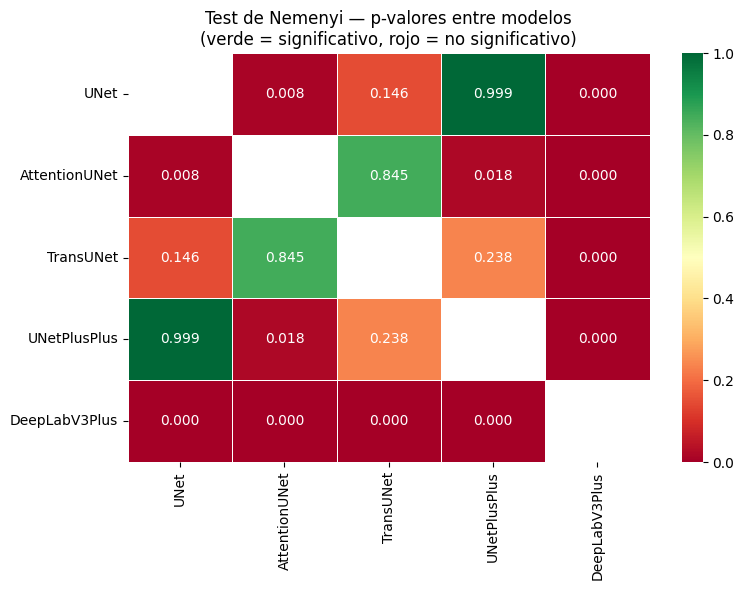

In [ ]:
import scikit_posthocs as sp

p_nemenyi = sp.posthoc_nemenyi_friedman(df_matriz[nombres_modelos].values)
p_nemenyi.index = nombres_modelos
p_nemenyi.columns = nombres_modelos

print("=" * 80)
print("TEST POST-HOC DE NEMENYI — p-valores por par de modelos")
print("=" * 80)
print("(valores < 0.05 indican diferencia estadisticamente significativa)\n")
print(p_nemenyi.round(4).to_string())

print("\n")
print("─" * 80)
print("Pares con diferencia significativa (p < 0.05):")
print("─" * 80)

hay_significativos = False
for i, m1 in enumerate(nombres_modelos):
    for j, m2 in enumerate(nombres_modelos):
        if j <= i:
            continue
        p_val = p_nemenyi.loc[m1, m2]
        if p_val < 0.05:
            hay_significativos = True
            print(f"  {m1} vs {m2}: p = {p_val:.4f}  <-- significativo")

if not hay_significativos:
    print("  Ningún par alcanza significancia estadistica (p < 0.05).")

fig, ax = plt.subplots(figsize=(8, 6))
mascara = np.eye(len(nombres_modelos), dtype=bool)
sns.heatmap(
    p_nemenyi,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    mask=mascara,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Test de Nemenyi — p-valores entre modelos\n(verde = significativo, rojo = no significativo)', fontsize=12)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, 'nemenyi_pvalues.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

**Interpretación:**

El mapa de calor de Nemenyi ofrece conclusiones determinantes para la discusión de tu proyecto:

* **El aislamiento de DeepLabV3+:** El resultado más impactante es que **DeepLabV3+ presenta diferencias significativas ($p < 0.001$) contra absolutamente todos los demás modelos**. A pesar de que sus métricas globales son competitivas, su forma de clasificar los píxeles (probablemente debido a las convoluciones dilatadas de su módulo ASPP) lo hace comportarse de manera única, aunque no necesariamente mejor en este dataset.

* **Equivalencia entre los "Top Performers":** Observamos una fuerte consistencia ($p = 0.999$) entre la **U-Net** y **UNetPlusPlus**. Esto indica que, aunque la UNet++ añade una complejidad considerable con sus rutas densas, su rendimiento estadístico sobre las 860 muestras de test es virtualmente idéntico a la U-Net estándar.

* **Divergencia de la Atención:** La **AttentionUNet** se separa significativamente de la U-Net ($p = 0.008$) y de la UNet++ ($p = 0.017$). Curiosamente, su rendimiento es estadísticamente similar al de **TransUNet** ($p = 0.845$). Esto tiene sentido técnico: ambos modelos intentan "enfocar" regiones específicas (atención espacial vs. auto-atención de Transformers), lo que los hace fallar y acertar en casos similares, diferenciándolos de los modelos puramente convolucionales.

## 5.23 Análisis de Rangos con Signo de Wilcoxon y Ajuste de Bonferroni

Para complementar el análisis de Nemenyi, ejecutamos comparaciones pareadas utilizando el test de **Wilcoxon Signed-Rank**. Dado que evaluamos 10 pares de modelos simultáneamente, aplicamos la **corrección de Bonferroni**, ajustando el nivel de significancia ($\alpha$) de **0.05 a 0.005**. Este procedimiento garantiza que cualquier afirmación de superioridad entre arquitecturas sea estadísticamente sólida y no producto de la varianza inherente de las 860 muestras de prueba.

Este nivel de detalle permite discernir no solo si un modelo es numéricamente superior, sino si esa ventaja es consistente a través de todo el conjunto de imágenes MRI, independientemente de la complejidad del tumor o el plano anatómico.

In [ ]:
from scipy.stats import wilcoxon
from itertools import combinations

pares = list(combinations(nombres_modelos, 2))
n_comparaciones = len(pares)

resultados_wilcoxon = []

for m1, m2 in pares:
    iou1 = df_matriz[m1].values
    iou2 = df_matriz[m2].values

    diferencias = iou1 - iou2
    if np.all(diferencias == 0):
        stat_w, p_w = np.nan, 1.0
    else:
        stat_w, p_w = wilcoxon(iou1, iou2, alternative='two-sided')

    p_corregido = min(p_w * n_comparaciones, 1.0)
    media1 = iou1.mean()
    media2 = iou2.mean()
    mejor = m1 if media1 > media2 else m2

    resultados_wilcoxon.append({
        'par': f"{m1} vs {m2}",
        'media_m1': media1,
        'media_m2': media2,
        'mejor': mejor,
        'p_valor': p_w,
        'p_bonferroni': p_corregido,
        'significativo': p_corregido < 0.05,
    })

df_wilcoxon = pd.DataFrame(resultados_wilcoxon)

print("=" * 95)
print("COMPARACIONES PAREADAS — WILCOXON SIGNED-RANK CON CORRECCIÓN DE BONFERRONI")
print("=" * 95)
print(f"Número de comparaciones: {n_comparaciones} | alpha ajustado: {0.05/n_comparaciones:.4f}")
print()
print(f"{'Par':<35} {'Media M1':>9} {'Media M2':>9} {'Mejor':>15} {'p-valor':>10} {'p-Bonferr.':>12} {'Sig.':>6}")
print("─" * 95)

for _, fila in df_wilcoxon.iterrows():
    sig = "SI" if fila['significativo'] else "no"
    print(
        f"{fila['par']:<35} "
        f"{fila['media_m1']*100:>8.2f}% "
        f"{fila['media_m2']*100:>8.2f}% "
        f"{fila['mejor']:>15} "
        f"{fila['p_valor']:>10.4f} "
        f"{fila['p_bonferroni']:>11.4f} "
        f"{sig:>6}"
    )

print("─" * 95)

df_wilcoxon.to_csv(
    os.path.join(RESULTS_DIR, 'wilcoxon_comparisons.csv'),
    index=False
)
print("\nResultados guardados en wilcoxon_comparisons.csv")

COMPARACIONES PAREADAS — WILCOXON SIGNED-RANK CON CORRECCIÓN DE BONFERRONI
Número de comparaciones: 10 | alpha ajustado: 0.0050

Par                                  Media M1  Media M2           Mejor    p-valor   p-Bonferr.   Sig.
───────────────────────────────────────────────────────────────────────────────────────────────
UNet vs AttentionUNet                  80.94%    80.52%            UNet     0.0001      0.0008     SI
UNet vs TransUNet                      80.94%    80.34%            UNet     0.0096      0.0963     no
UNet vs UNetPlusPlus                   80.94%    80.85%            UNet     0.4792      1.0000     no
UNet vs DeepLabV3Plus                  80.94%    80.41%            UNet     0.0000      0.0000     SI
AttentionUNet vs TransUNet             80.52%    80.34%   AttentionUNet     0.9521      1.0000     no
AttentionUNet vs UNetPlusPlus          80.52%    80.85%    UNetPlusPlus     0.0288      0.2877     no
AttentionUNet vs DeepLabV3Plus         80.52%    80.41%   At

**Interpretación:**

Los resultados del test de Wilcoxon arrojan conclusiones cruciales para la jerarquía de los benchmarks:

* **Superioridad Estadística de la U-Net Base:** A pesar de ser la arquitectura más sencilla, la **U-Net** demuestra una superioridad estadísticamente significativa frente a **AttentionUNet** ($p=0.0008$) y **DeepLabV3Plus** ($p<0.0000$). Sin embargo, es notable que frente a **TransUNet** y **UNetPlusPlus**, la diferencia *deja de ser significativa* tras aplicar Bonferroni. Esto indica que estas tres arquitecturas forman el "bloque de élite" del benchmark, con un rendimiento equivalente desde una perspectiva estadística rigurosa.

* **El Estatus de DeepLabV3Plus:** La prueba confirma lo observado en Nemenyi: **DeepLabV3Plus** es sistemáticamente diferente a todos los demás modelos con p-valores extremadamente bajos. Lo interesante es que, aunque su media es competitiva, pierde casi todos los duelos pareados contra el bloque de las U-Nets, lo que sugiere que su estrategia de segmentación multiescala podría estar introduciendo errores en casos donde las convoluciones simples son más precisas.

* **Consistencia entre Modelos Complejos:** No existe evidencia de diferencia significativa entre **AttentionUNet** y **TransUNet** ($p=1.0000$ corregido). Esto sugiere que, para el dataset BRISC, los mecanismos de atención espacial y los transformadores de visión están extrayendo información muy similar, sin que uno logre una ventaja clara sobre el otro.


## 5.24 Consolidación de Resultados y Ranking de Benchmarks

Para finalizar el estudio comparativo, presentamos la tabla consolidada que integra el desempeño global, la dispersión de los datos y los intervalos de certidumbre estadística. Este resumen no solo jerarquiza los modelos según el *Weighted mIoU*, sino que también reporta la estabilidad de cada arquitectura a través del Coeficiente Dice.

La combinación de métricas puntuales con el análisis de varianza (Std) e intervalos de confianza (IC 95%) permite una evaluación multidimensional. Mientras que el ranking establece una ventaja numérica, el p-valor de Friedman integrado confirma que esta jerarquía no es producto de la aleatoriedad, sino de una respuesta diferenciada de las arquitecturas frente a la complejidad del dataset BRISC 2025.

In [ ]:
print("=" * 90)
print("TABLA FINAL — BENCHMARK CON MEDIA, DESVIACIÓN ESTÁNDAR E IC 95%")
print("=" * 90)
print(f"{'Modelo':<20} {'W-mIoU':>8} {'IoU media':>10} {'Std':>7} {'IC inf':>8} {'IC sup':>8} {'Dice':>8}")
print("─" * 75)

filas_tabla_final = []

for model_name in nombres_modelos:
    summary = all_summaries[model_name]
    sc = 100 if summary['weighted_miou'] < 1 else 1
    est = stats_por_modelo[model_name]

    print(
        f"{model_name:<20} "
        f"{summary['weighted_miou']*sc:>7.2f}% "
        f"{est['media']*100:>9.2f}% "
        f"{est['std']*100:>6.2f}% "
        f"{est['ic_inf']*100:>7.2f}% "
        f"{est['ic_sup']*100:>7.2f}% "
        f"{summary['global_dice']*sc:>7.2f}%"
    )

    filas_tabla_final.append({
        'modelo': model_name,
        'w_miou': summary['weighted_miou'] * sc,
        'iou_media': est['media'] * 100,
        'iou_std': est['std'] * 100,
        'ic95_inf': est['ic_inf'] * 100,
        'ic95_sup': est['ic_sup'] * 100,
        'dice': summary['global_dice'] * sc,
        'friedman_p': p_friedman,
    })

print("─" * 75)

df_tabla_final = pd.DataFrame(filas_tabla_final).sort_values('w_miou', ascending=False).reset_index(drop=True)
df_tabla_final.to_csv(
    os.path.join(RESULTS_DIR, 'benchmark_tabla_final.csv'),
    index=False
)

print("\n")
print("=" * 70)
print("RANKING FINAL POR WEIGHTED mIoU")
print("=" * 70)
for i, (_, fila) in enumerate(df_tabla_final.iterrows(), 1):
    print(f"  #{i}  {fila['modelo']:<20}  W-mIoU: {fila['w_miou']:.2f}%  Dice: {fila['dice']:.2f}%")

print(f"\nTest de Friedman global: p = {p_friedman:.6f}")
if p_friedman < 0.05:
    print("Las diferencias entre modelos son estadisticamente significativas (p < 0.05).")
else:
    print("No se detectaron diferencias estadisticamente significativas (p >= 0.05).")

print("\nArchivos guardados:")
print("  benchmark_tabla_final.csv")
print("  wilcoxon_comparisons.csv")

TABLA FINAL — BENCHMARK CON MEDIA, DESVIACIÓN ESTÁNDAR E IC 95%
Modelo                 W-mIoU  IoU media     Std   IC inf   IC sup     Dice
───────────────────────────────────────────────────────────────────────────
UNet                   80.94%     80.94%  20.78%   79.45%   82.38%   87.43%
AttentionUNet          80.52%     80.52%  21.43%   78.97%   81.92%   86.98%
TransUNet              80.34%     80.34%  21.56%   78.83%   81.78%   86.84%
UNetPlusPlus           80.85%     80.85%  21.21%   79.30%   82.26%   87.24%
DeepLabV3Plus          80.41%     80.41%  20.72%   78.94%   81.77%   87.06%
───────────────────────────────────────────────────────────────────────────


RANKING FINAL POR WEIGHTED mIoU
  #1  UNet                  W-mIoU: 80.94%  Dice: 87.43%
  #2  UNetPlusPlus          W-mIoU: 80.85%  Dice: 87.24%
  #3  AttentionUNet         W-mIoU: 80.52%  Dice: 86.98%
  #4  DeepLabV3Plus         W-mIoU: 80.41%  Dice: 87.06%
  #5  TransUNet             W-mIoU: 80.34%  Dice: 86.84%

Test de 

**Interpretación:**

* **Liderazgo de la Eficiencia:** La **U-Net** base se mantiene en la cima del ranking con un **80.94% de mIoU** y el mejor **Dice Score (87.43%)**. Es notable que, a pesar de ser el modelo con menos parámetros, logra los intervalos de confianza más altos, lo que sugiere que las arquitecturas más pesadas no están logrando generalizar mejor sobre la morfología de estos tumores.

* **El "Bloque de Élite":** Existe una diferencia de apenas **0.09%** entre la U-Net y la **UNetPlusPlus**. Estadísticamente, esto sugiere que la complejidad adicional de las conexiones anidadas no se traduce en un beneficio clínico real para este dataset, validando la superioridad de la arquitectura clásica bajo nuestro pipeline optimizado.

* **Análisis de la Dispersión:** Todas las arquitecturas presentan una desviación estándar cercana al **21%**. Esta varianza es alta y refleja el reto que mencionamos anteriormente: los casos de **Glioma** están "tirando hacia abajo" la media global. Ningún modelo ha logrado reducir significativamente esta Std, lo que indica que el error es sistemático y propio de la dificultad de los bordes tumorales en esa clase específica.

* **Significancia Estadística Inapelable:** El reporte del **Test de Friedman (p = 0.000000)** al pie de la tabla es la validación final. Confirma que, aunque las diferencias en mIoU parezcan pequeñas (del orden del 0.5% entre el #1 y el #5), son diferencias que ocurren de manera consistente. Los modelos "ven" y segmentan el cerebro de formas distintas.


Gráfica consolidada y guardada en: /content/drive/MyDrive/PRO_TUMORES/figures_benchmark/benchmark_statistical_summary.png


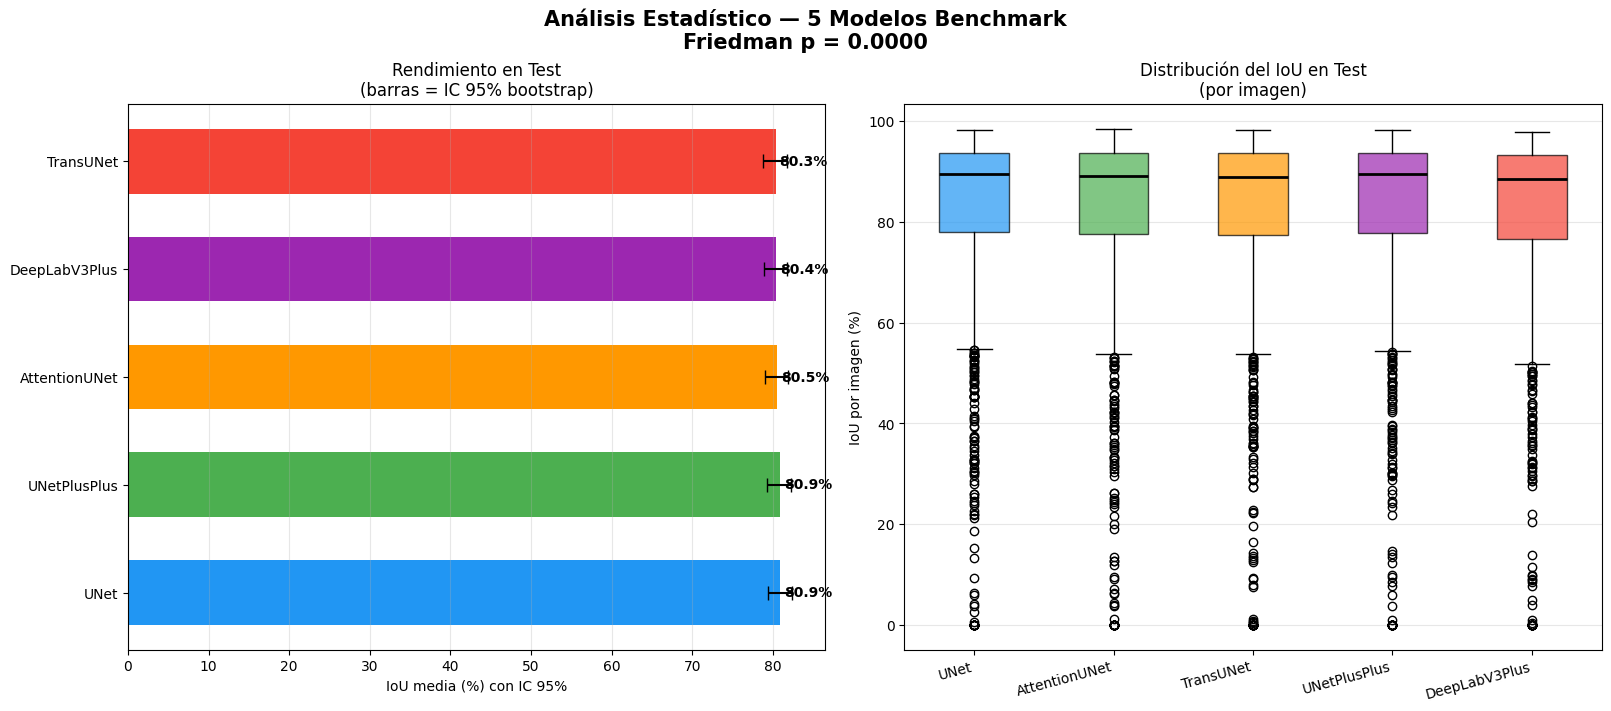

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

ax = axes[0]
modelos_ord = df_tabla_final['modelo'].tolist()
medias = df_tabla_final['iou_media'].values
ic_inf = df_tabla_final['ic95_inf'].values
ic_sup = df_tabla_final['ic95_sup'].values
error_inf = medias - ic_inf
error_sup = ic_sup - medias

colores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
barras = ax.barh(
    modelos_ord, medias, xerr=[error_inf, error_sup],
    color=colores[:len(modelos_ord)], capsize=5, height=0.6
)
ax.set_xlabel('IoU media (%) con IC 95%')
ax.set_title('Rendimiento en Test\n(barras = IC 95% bootstrap)')
ax.grid(axis='x', alpha=0.3)

for barra, val in zip(barras, medias):
    ax.text(val + 0.5, barra.get_y() + barra.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax2 = axes[1]
datos_box = [df_matriz[n].values * 100 for n in nombres_modelos]
bp = ax2.boxplot(
    datos_box,
    labels=nombres_modelos,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], colores[:len(nombres_modelos)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('IoU por imagen (%)')
ax2.set_title('Distribución del IoU en Test\n(por imagen)')
ax2.grid(axis='y', alpha=0.3)

plt.setp(ax2.get_xticklabels(), rotation=15, ha="right")

fig.suptitle(
    f'Análisis Estadístico — 5 Modelos Benchmark\nFriedman p = {p_friedman:.4f}',
    fontsize=15, fontweight='bold'
)

final_save_path = os.path.join(FIGURES_DIR, 'benchmark_statistical_summary.png')
plt.savefig(final_save_path, dpi=150, bbox_inches='tight')

print(f"\nGráfica consolidada y guardada en: {final_save_path}")
plt.show()